# Week 42, Monday lecture: from backpropagation to differential equations

**FYS-STK3155/4155, Monday October 12, 2026**

This notebook contains the code behind every figure and number in the Monday
slides (`week42slides.pdf`). It follows the lecture. The first part is the
reminder of week 41: the forward pass, the four equations of backpropagation
and how the algorithm is set up, the activation functions and why there must
be one, and the output activation for regression (linear), binary
classification (sigmoid) and $K$ classes (softmax), each paired with its cost
— with the code of week 41, unchanged, run on the Runge function of Project 1
and on MNIST. The rest of the notebook puts the *same network* to a different
use, following Chapter 9 of the lecture notes: solving differential equations
without any data, by driving the residual of the equation to zero — three
ordinary differential equations, the diffusion equation in one dimension, and
finally physics-informed neural networks with soft constraints and an inverse
problem.

The functions are the ones in `make_week41_figures.py` and
`make_week42_figures.py`; the seed is 2026 for the week-41 examples and the
seeds of Chapter 9 for the differential equations, so that the figures here
are the figures on the slides. Running everything takes two to three minutes.
One warning: the week-41 examples reproduce to every digit on any machine, but
the differential-equation runs of Parts 2–4 are long Adam descents on
non-convex costs, and rounding differences between platforms (CPU, JAX
version) change the path — on an Apple-silicon Mac the decay error comes out
at $1.2\times10^{-2}$ instead of $3\times10^{-3}$, the "stuck" Poisson seed
converges, and $D$ comes out at $0.515$ instead of $0.513$. The lessons do not
change; the third decimal does.

The weekly exercises (`exercisesweek42.ipynb`, deadline **Friday October
16**) write the backward pass of exactly this kind of network by hand and
check it against `jax.grad`; the Tuesday session does the same steps on a
problem of our own.

In [1]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp

BLUE, RED, YELLOW, GREY = "#004488", "#BB5566", "#DDAA33", "#777777"
GREEN = "#228833"
np.set_printoptions(precision=4, suppress=True)

## Part 1: the reminder — the network of week 41

### The forward pass and the four equations (Sections 8.5, 8.8.4)

With the samples in the rows of $\boldsymbol{A}^0 = \boldsymbol{X}$ and
$\boldsymbol{W}^l$ of shape $(M_{l-1}, M_l)$, the forward pass is
$\boldsymbol{Z}^l = \boldsymbol{A}^{l-1}\boldsymbol{W}^l + \boldsymbol{b}^l$,
$\boldsymbol{A}^l = f(\boldsymbol{Z}^l)$, Eq. (8.21), with the *output*
activation in the last layer, and every $\boldsymbol{Z}^l$ and
$\boldsymbol{A}^l$ is stored. The backward pass is the four equations
(8.65)–(8.68), written for a batch:

$$
\boldsymbol{\Delta}^L = f'(\boldsymbol{Z}^L)\circ \partial C/\partial\boldsymbol{A}^L
\;(=\boldsymbol{A}^L - \boldsymbol{Y}\text{ for the natural pairings, Eq. 8.69}),\qquad
\boldsymbol{\Delta}^l = \bigl(\boldsymbol{\Delta}^{l+1}(\boldsymbol{W}^{l+1})^T\bigr)\circ f'(\boldsymbol{Z}^l),
$$

$$
\frac{\partial C}{\partial \boldsymbol{b}^l} = \sum_{\text{samples}}\boldsymbol{\Delta}^l,\qquad
\frac{\partial C}{\partial \boldsymbol{W}^l} = (\boldsymbol{A}^{l-1})^T\boldsymbol{\Delta}^l .
$$

The error of a node is $\delta = \partial C/\partial z$; the gradient of a
weight is the error at the node it arrives at times the signal at the node it
leaves. Two transposes in two different places: $(\boldsymbol{W}^{l+1})^T$
sums over the *next layer*, $(\boldsymbol{A}^{l-1})^T$ over the *samples*.

### The algorithm, and the code it became (Sections 8.8.5, 8.13)

Five decisions before the first iteration: the architecture; the hidden
activation $f$ and its derivative $f'$; the output activation (the *range* of
the target) and the cost (its *distribution*) with any penalties; the
optimiser, its learning rate $\gamma$, the minibatch size and the number of
epochs; the initialisation. Then every iteration is a forward pass storing
$\boldsymbol{Z}^l$ and $\boldsymbol{A}^l$, the output error, the backward
pass, the gradients, and the update $w \leftarrow w - \gamma\,\partial
C/\partial w$ (8.70). The code below is the code of week 41, unchanged, with
one row added to the activation table: the hyperbolic tangent, which Part 2
needs.

In [2]:
def sigmoid(z):
    """The logistic function, Eq. (8.22), evaluated without overflow."""
    e = np.exp(-np.abs(z))
    return np.where(z >= 0, 1.0 / (1.0 + e), e / (1.0 + e))


def sigmoid_prime(z):
    s = sigmoid(z)
    return s * (1.0 - s)


def relu(z):
    """Eq. (8.23)."""
    return np.maximum(0.0, z)


def relu_prime(z):
    return (z > 0).astype(float)


def identity(z):
    return z


def identity_prime(z):
    return np.ones_like(z)


def softmax(z):
    """Eq. (8.75) with the shift of Eq. (5.30): rows are samples, columns classes."""
    e = np.exp(z - np.max(z, axis=1, keepdims=True))
    return e / np.sum(e, axis=1, keepdims=True)



ACTIVATIONS = {"sigmoid": (sigmoid, sigmoid_prime),
               "relu": (relu, relu_prime),
               "identity": (identity, identity_prime)}

# The output activation that goes with each cost function (Section 8.11)
OUTPUT = {"mse": identity, "binary": sigmoid, "softmax": softmax}


def tanh(z):
    """tanh(z) = 2 sigma(2z) - 1, Section 8.6.1: centred on zero, derivative up to 1."""
    return np.tanh(z)


def tanh_prime(z):
    return 1.0 - np.tanh(z) ** 2



ACTIVATIONS["tanh"] = (tanh, tanh_prime)      # the week-41 table, extended by one row

In [3]:
def create_layers(sizes, hidden_activation="sigmoid", rng=None):
    """A list of (W, b) pairs, W of shape (inputs, outputs) as in the template.

    sizes = [784, 100, 10] gives two layers: 784 -> 100 -> 10.  The weights are
    drawn with the variance of Eq. (8.74) (He) for ReLU and 1/inputs otherwise,
    the biases are set to 0.01 as in the template.
    """
    rng = np.random.default_rng(2026) if rng is None else rng
    layers = []
    for n_in, n_out in zip(sizes[:-1], sizes[1:]):
        scale = np.sqrt(2.0 / n_in) if hidden_activation == "relu" else np.sqrt(1.0 / n_in)
        W = rng.normal(0.0, scale, (n_in, n_out))
        b = np.zeros(n_out) + 0.01
        layers.append((W, b))
    return layers


def feed_forward(X, layers, hidden_activation="sigmoid", head="mse"):
    """Eq. (8.21) layer by layer, samples in rows.

    Returns the lists z (pre-activations) and a (activations, a[0] = X): every
    one of them is needed on the way back, so the forward pass stores them.
    """
    f, _ = ACTIVATIONS[hidden_activation]
    a, z = [X], []
    for l, (W, b) in enumerate(layers):
        zl = a[-1] @ W + b                       # the template's  x @ w_1 + b_1
        z.append(zl)
        if l == len(layers) - 1:
            a.append(OUTPUT[head](zl))           # the output head
        else:
            a.append(f(zl))
    return z, a


def predict(X, layers, hidden_activation="sigmoid", head="mse"):
    """The output of the network: a vector of predictions, probabilities, or class probabilities."""
    return feed_forward(X, layers, hidden_activation, head)[1][-1]


def cost(X, Y, layers, hidden_activation="sigmoid", head="mse", lmbd2=0.0, lmbd1=0.0):
    """The cost of Eq. (8.31): data term for the chosen head plus L2 and L1 penalties on the weights."""
    out = predict(X, layers, hidden_activation, head)
    n = X.shape[0]
    if head == "mse":                            # Eq. (8.32)
        data = 0.5 * np.sum((out - Y) ** 2) / n
    elif head == "binary":                       # Eq. (5.13), averaged
        p = np.clip(out, 1e-12, 1 - 1e-12)
        data = -np.mean(Y * np.log(p) + (1 - Y) * np.log(1 - p))
    else:                                        # Eq. (5.28), averaged, one-hot Y
        p = np.clip(out, 1e-12, 1.0)
        data = -np.mean(np.sum(Y * np.log(p), axis=1))
    reg = sum(lmbd2 * np.sum(W ** 2) + lmbd1 * np.sum(np.abs(W)) for W, _ in layers)
    return data + reg


def backpropagation(X, Y, layers, hidden_activation="sigmoid", head="mse", lmbd2=0.0, lmbd1=0.0):
    """Eqs. (8.65)-(8.68) for all samples at once; returns a list of (dW, db) with the shapes of (W, b)."""
    _, fp = ACTIVATIONS[hidden_activation]
    n = X.shape[0]
    z, a = feed_forward(X, layers, hidden_activation, head)
    delta = (a[-1] - Y) / n                      # Eq. (8.69): the same line for all three heads
    grads = [None] * len(layers)
    for l in range(len(layers) - 1, -1, -1):
        W, _ = layers[l]
        dW = a[l].T @ delta                      # Eq. (8.68): outer products, summed over the samples
        dW += 2.0 * lmbd2 * W + lmbd1 * np.sign(W)   # the penalties of Section 8.12 (weights only)
        db = np.sum(delta, axis=0)               # Eq. (8.67)
        grads[l] = (dW, db)
        if l > 0:
            delta = (delta @ W.T) * fp(z[l - 1])     # Eq. (8.66): pull back through W, modulate by f'
    return grads


def accuracy(X, y, layers, hidden_activation, head):
    """Fraction of correct labels; y holds integer labels for softmax, 0/1 for binary."""
    out = predict(X, layers, hidden_activation, head)
    if head == "softmax":
        return np.mean(np.argmax(out, axis=1) == y)
    return np.mean((out[:, 0] > 0.5) == (y > 0.5))


def train(X, Y, layers, hidden_activation="sigmoid", head="mse", gamma=0.1, epochs=100,
          batch_size=None, lmbd2=0.0, lmbd1=0.0, rng=None, X_test=None, y_test=None, verbose=False):
    """Plain gradient descent, Eq. (8.70), on minibatches (batch_size=None: the whole set).

    Returns the trained layers and a history with the training cost after
    every epoch and, when a test set is given, the test accuracy.
    """
    rng = np.random.default_rng(2026) if rng is None else rng
    n = X.shape[0]
    M = n if batch_size is None else batch_size
    history = {"cost": [], "test_accuracy": []}
    for epoch in range(epochs):
        order = rng.permutation(n)
        for s in range(0, n, M):
            idx = order[s:s + M]
            grads = backpropagation(X[idx], Y[idx], layers, hidden_activation, head, lmbd2, lmbd1)
            layers = [(W - gamma * dW, b - gamma * db) for (W, b), (dW, db) in zip(layers, grads)]
        history["cost"].append(cost(X, Y, layers, hidden_activation, head, lmbd2, lmbd1))
        if X_test is not None:
            history["test_accuracy"].append(accuracy(X_test, y_test, layers, hidden_activation, head))
        if verbose:
            msg = f"epoch {epoch + 1:3d}: cost {history['cost'][-1]:.4f}"
            if X_test is not None:
                msg += f"  test accuracy {history['test_accuracy'][-1]:.4f}"
            print(msg)
    return layers, history


def one_hot(y, n_classes=None):
    """Integer labels -> one-hot rows."""
    n_classes = int(np.max(y)) + 1 if n_classes is None else n_classes
    Y = np.zeros((len(y), n_classes))
    Y[np.arange(len(y)), y] = 1.0
    return Y


### Activation functions: what matters is the derivative (Section 8.6)

In the backward pass only $f'$ appears, Eq. (8.66), so what decides whether a
gradient survives its passage through a layer is the derivative. The sigmoid
has $\sigma' = \sigma(1-\sigma) \le 1/4$ and saturates; $\tanh(z) =
2\sigma(2z) - 1$ is centred on zero with $\tanh' = 1 - \tanh^2 \le 1$, always
the better of the two in a hidden layer; the ReLU has $f' = 1$ on the active
side and passes the gradient undiminished, at the price of *dying* units. The
hidden activation must be non-linear — Section 8.4: *not a polynomial* — or
the network collapses to a single linear map. And, the third rule for today:
when the *output* of the network is differentiated with respect to its
*input*, $f''$ appears as well, and for the whole rectified family $f'' \equiv
0$.

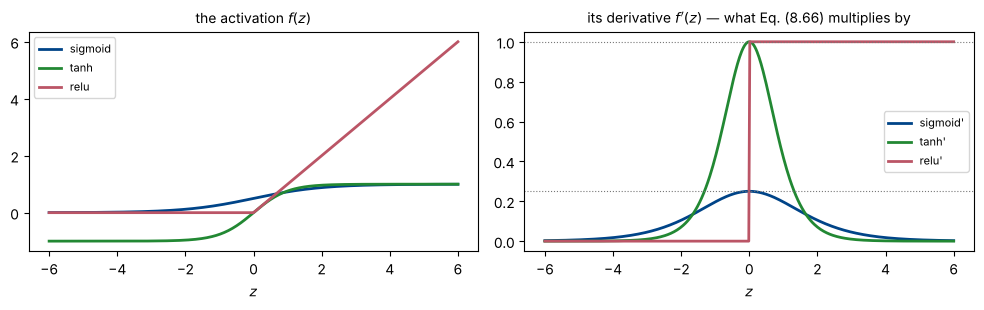

In [4]:
z = np.linspace(-6, 6, 400)
fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
for name, col in (("sigmoid", BLUE), ("tanh", GREEN), ("relu", RED)):
    f, fp = ACTIVATIONS[name]
    ax[0].plot(z, f(z), color=col, lw=2, label=name)
    ax[1].plot(z, fp(z), color=col, lw=2, label=name + "'")
ax[1].axhline(0.25, color=GREY, lw=0.8, ls=":")
ax[1].axhline(1.0, color=GREY, lw=0.8, ls=":")
for a, t in zip(ax, ("the activation $f(z)$", "its derivative $f'(z)$ — what Eq. (8.66) multiplies by")):
    a.set_xlabel("$z$"); a.set_title(t, fontsize=10); a.legend(fontsize=8)
fig.tight_layout()
plt.show()

### Why a hidden layer with a non-linear activation fits a non-linear function (Section 8.4)

A network with one hidden layer and a linear output is a universal
approximator *if and only if* the hidden activation is not a polynomial
(Leshno et al. 1993). For ReLU in one dimension the statement is
constructive: $g(x) = c + \sum_i v_i\,\mathrm{ReLU}(w_i x + b_i)$ is
continuous and piecewise linear with at most $N+1$ pieces and kinks at $-b_i/w_i$
(Lemma 8.1), every such function is such a network, and with the kinks at
$N+1$ equally spaced knots and the $v_i$ the changes of slope of the chords
the network is the piecewise-linear interpolant, with $\sup|F - g| \le
L(b-a)/(2N)$ for an $L$-Lipschitz $F$ (Theorem 8.2). A hidden unit is a kink;
the output layer adds kinks with weights; the non-linearity is what lets the
sum bend.

### Example A: the Runge function with ReLU, sigmoid and tanh hidden units

The data of Project 1 ($n = 100$, $\sigma = 0.1$, seed 2026, a separate test
set), the 1–50–1 network with the linear output and the half-squared error,
plain gradient descent, 20 000 steps. Panel (c) shows the ten largest hidden
units of the ReLU network, each a kink, and their sum — Lemma 8.1 after
training rather than by construction.

In [5]:
def runge_data(n=100, sigma=0.1, seed=2026):
    """The data of Project 1: x uniform on [-1, 1], y = 1/(1 + 25 x^2) + noise; a train and a test set."""
    rng = np.random.default_rng(seed)
    x = np.sort(rng.uniform(-1, 1, n))
    y = 1.0 / (1.0 + 25 * x ** 2) + rng.normal(0, sigma, n)
    x_test = np.sort(rng.uniform(-1, 1, n))
    y_test = 1.0 / (1.0 + 25 * x_test ** 2) + rng.normal(0, sigma, n)
    return x[:, None], y[:, None], x_test[:, None], y_test[:, None]


def fig_runge_activations(fname="week42_runge.pdf", hidden=50, epochs=20000,
                          gammas=(("relu", 0.1), ("sigmoid", 0.2), ("tanh", 0.1))):
    """The 1-50-1 network of week 41 on the Runge data: ReLU, sigmoid and tanh hidden units."""
    X, Y, Xt, Yt = runge_data()
    xx = np.linspace(-1, 1, 400)[:, None]
    results, fits, hists = {}, {}, {}
    for act, gamma in gammas:
        layers = create_layers([1, hidden, 1], act, np.random.default_rng(2026))
        layers, hist = train(X, Y, layers, act, "mse", gamma=gamma, epochs=epochs)
        tr = np.mean((predict(X, layers, act, "mse") - Y) ** 2)
        te = np.mean((predict(Xt, layers, act, "mse") - Yt) ** 2)
        results[act] = {"gamma": gamma, "train": tr, "test": te, "cost_100": hist["cost"][100]}
        fits[act], hists[act] = layers, hist["cost"]

    fig, ax = plt.subplots(1, 3, figsize=(12, 3.6))
    ax[0].plot(X, Y, "o", color=GREY, ms=3, label="training data")
    ax[0].plot(xx, 1 / (1 + 25 * xx ** 2), color="k", lw=1, ls=":", label="Runge function")
    for (act, _), col, ls in zip(gammas, (BLUE, RED, GREEN), ("-", "-", "--")):
        ax[0].plot(xx, predict(xx, fits[act], act, "mse"), color=col, lw=2, ls=ls,
                   label=rf"{act}, $\gamma={results[act]['gamma']}$: test MSE {results[act]['test']:.4f}")
    ax[0].set_xlabel("$x$")
    ax[0].set_ylabel("$y$")
    ax[0].legend(fontsize=7, loc="upper left")
    ax[0].set_title(f"(a) 1-{hidden}-1 network, {epochs} GD steps", fontsize=10)
    for (act, _), col, ls in zip(gammas, (BLUE, RED, GREEN), ("-", "-", "--")):
        ax[1].loglog(np.arange(1, epochs + 1), hists[act], color=col, lw=1.5, ls=ls, label=act)
    ax[1].axhline(0.005, color=GREY, lw=0.8, ls=":", label=r"$\sigma^2/2$, the noise floor")
    ax[1].set_xlabel("gradient-descent step")
    ax[1].set_ylabel("training cost $C$ (half-squared error)")
    ax[1].legend(fontsize=8)
    ax[1].set_title("(b) the cost during training", fontsize=10)
    (W1, b1), (W2, b2) = fits["relu"]
    contrib = W2[:, 0][None, :] * relu(xx * W1[0][None, :] + b1[None, :])     # (400, hidden)
    order = np.argsort(-np.abs(contrib).max(axis=0))[:10]
    for j in order:
        ax[2].plot(xx, contrib[:, j], lw=1, color=GREY)
    ax[2].plot(xx, contrib.sum(axis=1) + b2[0], color=BLUE, lw=2, label=r"$\sum_j w_j^2\,\mathrm{ReLU}(w_j^1x+b_j^1)+b^2$")
    ax[2].plot(xx, 1 / (1 + 25 * xx ** 2), color="k", lw=1, ls=":", label="Runge function")
    ax[2].set_xlabel("$x$")
    ax[2].set_ylabel("contribution of hidden unit $j$")
    ax[2].legend(fontsize=7, loc="upper left")
    ax[2].set_title("(c) the ten largest ReLU units: a sum of kinks", fontsize=10)
    fig.tight_layout()
    fig.savefig(fname)
    fig.savefig(fname.replace(".pdf", ".png"), dpi=150)
    plt.close(fig)
    kinks = -b1 / W1[0]
    results["kinks_inside"] = int(np.sum((kinks > -1) & (kinks < 1)))
    results["dead_units"] = int(np.sum(np.all(xx * W1[0][None, :] + b1[None, :] <= 0, axis=0)))
    return results


relu     gamma 0.1: train MSE 0.0128  test MSE 0.0094  cost after 100 steps 0.0128
sigmoid  gamma 0.2: train MSE 0.0169  test MSE 0.0124  cost after 100 steps 0.0461
tanh     gamma 0.1: train MSE 0.0152  test MSE 0.0111  cost after 100 steps 0.0386
ReLU network: 50 of 50 kinks inside [-1, 1], 0 units never active  (11 s)


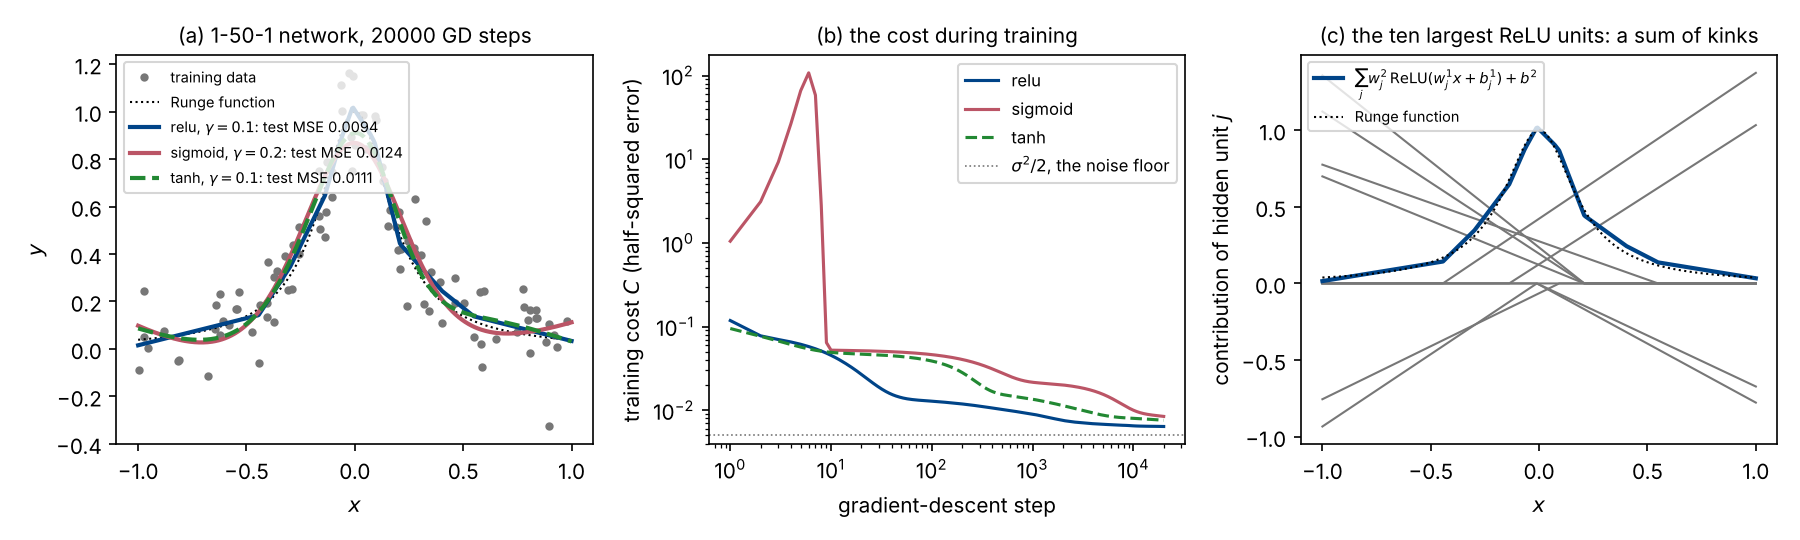

In [6]:
t0 = time.time()
res = fig_runge_activations()
for act in ("relu", "sigmoid", "tanh"):
    v = res[act]
    print(f"{act:8s} gamma {v['gamma']}: train MSE {v['train']:.4f}  test MSE {v['test']:.4f}  cost after 100 steps {v['cost_100']:.4f}")
print(f"ReLU network: {res['kinks_inside']} of 50 kinks inside [-1, 1], {res['dead_units']} units never active  ({time.time() - t0:.0f} s)")
Image("week42_runge.png", width=1000)

**Pause and think 1: how many ReLU units does the Runge function need?**
Theorem 8.2 guarantees $\sup|F-g| \le L(b-a)/(2N)$ with $L = \max|F'| \approx
3.25$ for the Runge function on $[-1, 1]$, so $N \ge 3.25\cdot 2/0.02 = 325$
units for an error of $0.01$ — and the trained network used 50 (week 41's
$\ell_1$ run kept ten). The bound is a worst case for equally spaced kinks and
any Lipschitz function; training puts the kinks where the function bends and
leaves the flat tails to one or two units each. With the identity as hidden
activation the network is $\alpha x + \beta$, a straight line, and the best
fit is the horizontal line at the mean, MSE $0.10$: no kinks without a
non-linearity.

### Output activations: three tasks, three heads, one output error (Sections 8.11, 5.3, 5.6)

| Task | Output activation | Loss (one sample) | Likelihood of | $\delta^L$ |
|---|---|---|---|---|
| regression, $y\in\mathbb{R}$ | linear, $a^L = z^L$ | $\frac12(a^L-y)^2$ | a Gaussian | $a^L - y$ |
| binary, $y\in\{0,1\}$ | sigmoid, $a^L = \sigma(z^L)$ | $-y\ln a^L - (1-y)\ln(1-a^L)$ | a Bernoulli | $a^L - y$ |
| $K$ classes, $\boldsymbol{y}$ one-hot | softmax, $a_k^L = e^{z_k^L}/\sum_l e^{z_l^L}$ | $-\sum_k y_k \ln a_k^L$ | a categorical | $\boldsymbol{a}^L - \boldsymbol{y}$ |

For the sigmoid the $\sigma'$ that shrinks every squared-error gradient is
divided out by the denominator of the cross entropy; for the softmax the
Jacobian $\partial a_k/\partial z_j = a_k(\delta_{kj} - a_j)$ is not diagonal,
but $\sum_k (-y_k/a_k)\, a_k(\delta_{kj} - a_j) = a_j - y_j$. The backward
pass therefore starts with the same line, `delta = (a[-1] - Y)/n`, for all
three heads — and a confident *wrong* answer gives the largest error, which is
what makes the pairing work (`week41_delta_heads.pdf`). A linear output can be
7; a sigmoid output is a probability; a softmax output is a distribution over
$K$ classes computed from scores that are only defined up to a common shift.

### Example B: the sigmoid and the softmax head on MNIST

The code above, unchanged: a 784–32–1 ReLU network with the sigmoid output and
the cross entropy on the threes and eights (is it an 8?), and the 784–100–10
network of week 41 with the softmax and the multiclass cross entropy on all
ten digits. The data come from the repository's `mnist.npz` (in
`BookPrograms/chapter10_convolutional_networks/`); if it is not found, the
loader downloads the set with `fetch_openml`.

In [7]:
def load_mnist():
    """The 70 000 MNIST images as (X_train, y_train, X_test, y_test), pixels scaled to [0, 1], 784 columns.

    Looks for the repository's mnist.npz first (no download needed) and falls
    back on scikit-learn's fetch_openml, which downloads 70 000 images once.
    """
    here = os.path.dirname(os.path.abspath(__file__)) if "__file__" in globals() else os.getcwd()
    candidates = [os.path.join(here, "mnist.npz"),
                  os.path.join(here, "..", "BookPrograms", "chapter10_convolutional_networks", "mnist.npz"),
                  os.path.join(here, "..", "..", "BookML", "BookPrograms", "chapter10_convolutional_networks", "mnist.npz")]
    for path in candidates:
        if os.path.exists(path):
            d = np.load(path)
            X_train = d["x_train"].reshape(len(d["x_train"]), -1).astype(float) / 255.0
            X_test = d["x_test"].reshape(len(d["x_test"]), -1).astype(float) / 255.0
            return X_train, d["y_train"].astype(int), X_test, d["y_test"].astype(int)
    from sklearn.datasets import fetch_openml
    mnist = fetch_openml("mnist_784", version=1, as_frame=False)
    X = mnist.data.astype(float) / 255.0
    y = mnist.target.astype(int)
    return X[:60000], y[:60000], X[60000:], y[60000:]


def mnist_heads(epochs=20, hidden=100, batch_size=100, verbose=False):
    """A 784-32-1 sigmoid-output network on the threes and eights, and the 784-100-10 softmax network of week 41."""
    X_train, y_train, X_test, y_test = load_mnist()
    out = {}
    # binary: is it an 8?  (threes and eights only)
    tr = np.isin(y_train, (3, 8))
    te = np.isin(y_test, (3, 8))
    Xb, yb = X_train[tr], (y_train[tr] == 8).astype(float)
    Xbt, ybt = X_test[te], (y_test[te] == 8).astype(float)
    t0 = time.time()
    layers = create_layers([784, 32, 1], "relu", np.random.default_rng(2026))
    layers, hist = train(Xb, yb[:, None], layers, "relu", "binary", gamma=0.1, epochs=10,
                         batch_size=batch_size, X_test=Xbt, y_test=ybt, verbose=verbose)
    p = predict(Xbt, layers, "relu", "binary")[:, 0]
    out["binary"] = {"layers": layers, "history": hist, "time": time.time() - t0, "n_train": len(yb), "n_test": len(ybt),
                     "train_accuracy": accuracy(Xb, yb, layers, "relu", "binary"),
                     "test_accuracy": hist["test_accuracy"][-1], "p_test": p, "y_test": ybt, "X_test": Xbt,
                     "n_wrong": int(np.sum((p > 0.5) != (ybt > 0.5))),
                     "n_unsure": int(np.sum((p > 0.2) & (p < 0.8)))}
    # ten classes: the week-41 network with ReLU
    t0 = time.time()
    layers = create_layers([784, hidden, 10], "relu", np.random.default_rng(2026))
    layers, hist = train(X_train, one_hot(y_train, 10), layers, "relu", "softmax", gamma=0.1, epochs=epochs,
                         batch_size=batch_size, X_test=X_test, y_test=y_test, verbose=verbose)
    P = predict(X_test, layers, "relu", "softmax")
    z, _ = feed_forward(X_test, layers, "relu", "softmax")
    out["softmax"] = {"layers": layers, "history": hist, "time": time.time() - t0,
                      "train_accuracy": accuracy(X_train, y_train, layers, "relu", "softmax"),
                      "test_accuracy": hist["test_accuracy"][-1], "P_test": P, "Z_test": z[-1], "y_test": y_test,
                      "X_test": X_test}
    return out


def fig_mnist_heads(out, fname="week42_mnist.pdf"):
    b, s = out["binary"], out["softmax"]
    fig = plt.figure(figsize=(12, 3.8))
    gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 1.25], wspace=0.32)
    ax0 = fig.add_subplot(gs[0])
    bins = np.linspace(0, 1, 41)
    ax0.hist(b["p_test"][b["y_test"] == 0], bins=bins, color=BLUE, alpha=0.8, label="true 3")
    ax0.hist(b["p_test"][b["y_test"] == 1], bins=bins, color=RED, alpha=0.8, label="true 8")
    ax0.axvline(0.5, color=GREY, lw=1, ls="--")
    ax0.set_yscale("log")
    ax0.set_xlabel(r"sigmoid output $a^L=p(8\mid\mathbf{x})$")
    ax0.set_ylabel("test images")
    ax0.legend(fontsize=8)
    ax0.set_title(f"(a) 3 against 8: test accuracy {100 * b['test_accuracy']:.2f}%", fontsize=10)
    ax1 = fig.add_subplot(gs[1])
    ep = np.arange(1, len(s["history"]["cost"]) + 1)
    ax1.plot(ep, 100 * np.array(s["history"]["test_accuracy"]), "o-", color=RED, ms=3,
             label=f"test: {100 * s['test_accuracy']:.2f}%")
    ax1.set_ylim(90, 100)
    ax1.set_xlabel("epoch")
    ax1.set_ylabel("accuracy (%)")
    ax1.legend(fontsize=8, loc="lower right")
    ax1.set_title("(b) ten digits, 784-100-10, ReLU, softmax", fontsize=10)
    # two test images: the most confident correct one among the first hundred and the least confident
    P, Z, y = s["P_test"], s["Z_test"], s["y_test"]
    pred = np.argmax(P, axis=1)
    pmax = P.max(axis=1)
    i_sure = int(np.argmax(np.where(pred == y, pmax, -1)))
    i_unsure = int(np.argmin(pmax))
    gs2 = gs[2].subgridspec(2, 2, width_ratios=[1, 2.2], wspace=0.15, hspace=0.5)
    for row, i in enumerate((i_sure, i_unsure)):
        axi = fig.add_subplot(gs2[row, 0])
        axi.imshow(s["X_test"][i].reshape(28, 28), cmap="gray_r")
        axi.set_title(f"true {y[i]}", fontsize=8, pad=2)
        axi.axis("off")
        axb = fig.add_subplot(gs2[row, 1])
        k = np.arange(10)
        axb.bar(k - 0.2, Z[i] / np.abs(Z[i]).max(), width=0.4, color=GREY, label=r"scores $z_k$ (scaled)")
        axb.bar(k + 0.2, P[i], width=0.4, color=RED, label=r"softmax $a_k$")
        axb.set_xticks(k)
        axb.tick_params(labelsize=7)
        axb.set_ylim(-1.05, 1.05)
        axb.axhline(0, color="k", lw=0.5)
        if row == 0:
            axb.legend(fontsize=6, loc="upper right", ncol=2)
        axb.set_title(f"predicted {pred[i]} with probability {100 * pmax[i]:.0f}%", fontsize=8)
    fig.text(0.70, 0.93, "(c) scores and probabilities of two test images", fontsize=10, ha="left")
    fig.subplots_adjust(left=0.05, right=0.99, top=0.88, bottom=0.15)
    fig.savefig(fname)
    fig.savefig(fname.replace(".pdf", ".png"), dpi=150)
    plt.close(fig)
    return {"sure": (int(y[i_sure]), int(pred[i_sure]), float(pmax[i_sure])),
            "unsure": (int(y[i_unsure]), int(pred[i_unsure]), float(pmax[i_unsure]), np.sort(P[i_unsure])[::-1][:3])}


3 against 8: 11982 training and 1984 test images, 784-32-1, ReLU, sigmoid output, 10 epochs: train 0.9879  test 0.9824  (35 wrong, 61 with 0.2 < p < 0.8)  1 s
ten digits: 784-100-10, ReLU, softmax, 20 epochs: train 0.9897  test 0.9763  20 s


most confident correct test image: true 0, predicted 0 with p = 1.0000
least confident test image: true 1, predicted 1 with p = 0.2400, top three probabilities [0.24   0.198  0.1867]
(22 s)


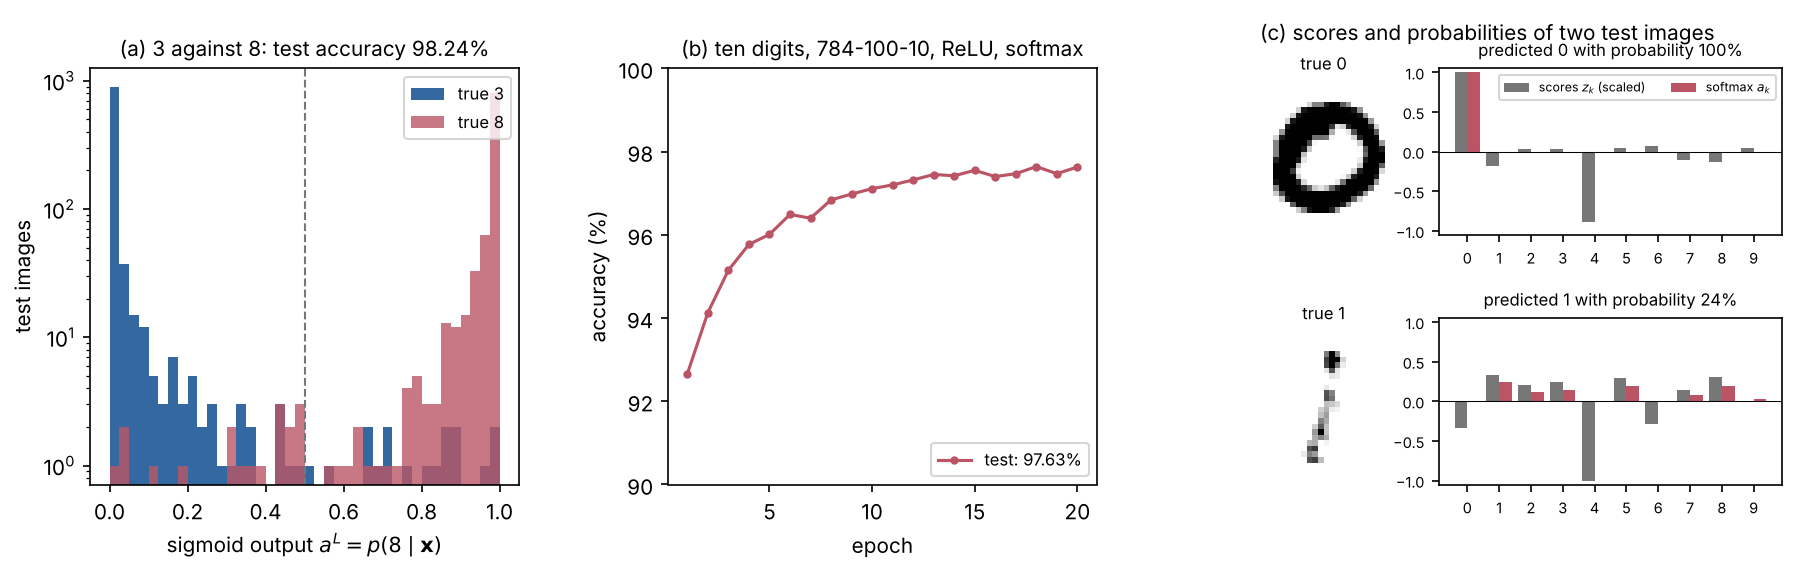

In [8]:
t0 = time.time()
outm = mnist_heads()
b, s = outm["binary"], outm["softmax"]
print(f"3 against 8: {b['n_train']} training and {b['n_test']} test images, 784-32-1, ReLU, sigmoid output, 10 epochs: "
      f"train {b['train_accuracy']:.4f}  test {b['test_accuracy']:.4f}  ({b['n_wrong']} wrong, {b['n_unsure']} with 0.2 < p < 0.8)  {b['time']:.0f} s")
print(f"ten digits: 784-100-10, ReLU, softmax, 20 epochs: train {s['train_accuracy']:.4f}  test {s['test_accuracy']:.4f}  {s['time']:.0f} s")
pick = fig_mnist_heads(outm)
print(f"most confident correct test image: true {pick['sure'][0]}, predicted {pick['sure'][1]} with p = {pick['sure'][2]:.4f}")
print(f"least confident test image: true {pick['unsure'][0]}, predicted {pick['unsure'][1]} with p = {pick['unsure'][2]:.4f}, "
      f"top three probabilities {pick['unsure'][3]}")
print(f"({time.time() - t0:.0f} s)")
Image("week42_mnist.png", width=1000)

**Pause and think 2: which of the two images trains the network?** The
backward pass starts with $\delta^L = a^L - y$. For the zero predicted with
probability 1.0000, $\delta_0 \approx 0$ and every other $\delta_k = a_k
\approx 0$: a confident correct answer is finished and contributes nothing to
$(\boldsymbol{A}^{L-1})^T\boldsymbol{\Delta}^L$. For the one predicted with
$24\%$, $\delta_1 = 0.24 - 1 = -0.76$ and $\delta_k = +0.20, +0.19, \dots$ for
the rivals: a strong push that raises the score of class 1 and lowers the
others, and the $K$ errors sum to zero. With the squared error on the softmax
the Jacobian $a_k(\delta_{kj} - a_j)$ would stay in the output error, and for
a confident wrong answer every factor $a_k(1 - a_k)$ is small: the network
would learn least from exactly the mistakes it is surest about. The pairing of
Eq. (8.69) is what makes the confident mistakes the loudest ones.

## Part 2: differential equations without data (Chapter 9, Sections 9.1–9.5)

### The equation is the cost

An ordinary differential equation $f(x, g, g', \dots, g^{(n)}) = 0$,
Eq. (9.1), with initial or boundary conditions. Nobody hands us values
$g(x_i)$: what we have is the equation. The central device is the *trial
solution*, Eq. (9.2),

$$
g_t(x, P) = h_1(x) + h_2\bigl(x, N(x, P)\bigr),
$$

where $N(x, P)$ is our network, $h_1$ alone satisfies the conditions and $h_2$
is built so that the network's contribution *vanishes* wherever a condition is
imposed. The conditions then hold exactly, for every $P$, and the optimiser
has one job: make the equation hold. The cost, Eq. (9.3), is the mean squared
residual at $N$ *collocation points* $x_i$ that we choose,

$$
C(\boldsymbol{x}, P) = \frac1N \sum_{i=1}^N \Bigl(f\bigl(x_i, g_t(x_i), g_t'(x_i), \dots\bigr)\Bigr)^2 .
$$

It is a mean squared error, so Chapter 4 applies unchanged (the Adam of week
38, with the residual in the role of the target); it is not convex; and it
needs $g_t'$, hence $\partial N/\partial x$ — a derivative with respect to the
*input*, not the parameters.

### Differentiating the network with respect to its input (Section 9.2)

Differentiating the forward pass with respect to an input coordinate $x_k$,
starting from $\partial\boldsymbol{a}^0/\partial x_k = \boldsymbol{e}_k$, gives
the forward recursions (9.5) and (9.6),

$$
\frac{\partial \boldsymbol{z}^l}{\partial x_k} = \frac{\partial \boldsymbol{a}^{l-1}}{\partial x_k}\boldsymbol{W}^l,\quad
\frac{\partial \boldsymbol{a}^l}{\partial x_k} = f'(\boldsymbol{z}^l)\circ\frac{\partial \boldsymbol{z}^l}{\partial x_k},\qquad
\frac{\partial^2 \boldsymbol{a}^l}{\partial x_k^2} = f''(\boldsymbol{z}^l)\circ\Bigl(\frac{\partial \boldsymbol{z}^l}{\partial x_k}\Bigr)^2 + f'(\boldsymbol{z}^l)\circ\frac{\partial^2 \boldsymbol{z}^l}{\partial x_k^2}.
$$

The derivatives travel *forward* with the activations — forward-mode automatic
differentiation, the right mode for one input and many parameters. The
function `network_derivs` below transcribes the recursions in numpy with the
week-41 activation table; `network` is the week-41 forward pass written in
`jax.numpy`, and `d_dxk` differentiates any function of the input matrix with
respect to one column, one row at a time, by `jax.grad` — nested, it gives the
second derivative. We check the hand recursion against JAX.

In [9]:
JAX_ACTIVATIONS = {"tanh": jnp.tanh, "sigmoid": jax.nn.sigmoid, "relu": jax.nn.relu,
                   "leaky_relu": jax.nn.leaky_relu, "elu": jax.nn.elu, "gelu": jax.nn.gelu,
                   "swish": jax.nn.swish, "softplus": jax.nn.softplus}


def network(layers, X, activation="tanh"):
    """The feed-forward pass of week 41 (Eq. 8.21) in jax.numpy, linear output; returns N(x) as a vector.

    `layers` is the list of (W, b) pairs of create_layers; X has the inputs in
    rows (one column for an ODE, two for a PDE in x and t).
    """
    f = JAX_ACTIVATIONS[activation]
    a = X
    for l, (W, b) in enumerate(layers):
        z = a @ W + b
        a = f(z) if l < len(layers) - 1 else z      # linear output: the "mse" head of week 41
    return a[:, 0]


def network_derivs(layers, X, activation="tanh", k=0):
    """N, dN/dx_k and d2N/dx_k^2 by the forward recursions of Eqs. (9.5) and (9.6), in numpy.

    The derivatives are propagated FORWARD through the layers, alongside the
    ordinary forward pass: one extra matrix product per layer and per
    derivative order, so three forward passes in all.  Needs f, f' and f''
    of the hidden activation.
    """
    f, fp = ACTIVATIONS[activation]
    fpp = {"tanh": lambda z: -2.0 * np.tanh(z) * (1.0 - np.tanh(z) ** 2),
           "sigmoid": lambda z: sigmoid_prime(z) * (1.0 - 2.0 * sigmoid(z)),
           "relu": lambda z: np.zeros_like(z)}[activation]
    a = np.asarray(X, dtype=float)
    da = np.zeros_like(a) + (np.arange(a.shape[1]) == k)          # d a^0 / d x_k = e_k
    d2a = np.zeros_like(a)
    for l, (W, b) in enumerate(layers):
        W, b = np.asarray(W), np.asarray(b)
        z, dz, d2z = a @ W + b, da @ W, d2a @ W
        if l < len(layers) - 1:
            a, da, d2a = f(z), fp(z) * dz, fpp(z) * dz ** 2 + fp(z) * d2z   # Eqs. (9.5), (9.6)
        else:
            a, da, d2a = z, dz, d2z                                        # linear output
    return a[:, 0], da[:, 0], d2a[:, 0]


def d_dxk(fun, k):
    """Partial derivative of fun(layers, X) -- a vector, one value per row of X -- with respect to input column k.

    Each row is differentiated on its own (jax.grad of a scalar function of
    one coordinate, vectorised over the rows with jax.vmap).  Nesting gives
    higher derivatives: d_dxk(d_dxk(u, 0), 0) is the second derivative with
    respect to x_0.  This is what we use for the trial solutions of the PDEs,
    where differentiating by hand is error-prone drudgery.
    """
    def wrapped(layers, X):
        def one_row(xk, row):
            return fun(layers, row.at[k].set(xk)[None, :])[0]
        return jax.vmap(jax.grad(one_row), in_axes=(0, 0))(X[:, k], X)
    return wrapped


def to_jax(layers):
    """numpy (W, b) pairs from create_layers -> jax arrays (so that jax.grad can trace through them)."""
    return [(jnp.asarray(W), jnp.asarray(b)) for W, b in layers]


def second_derivative_table(sizes=(1, 20, 20, 1), n_points=200):
    """max |d2N/dx2| over [-2, 2] for a freshly initialised network, by activation (Section 9.2)."""
    X = jnp.linspace(-2, 2, n_points)[:, None]
    table = {}
    for act in JAX_ACTIVATIONS:
        init_act = "relu" if act in ("relu", "leaky_relu", "elu") else "sigmoid"
        layers = to_jax(create_layers(list(sizes), init_act, np.random.default_rng(2026)))
        u = lambda L, X, act=act: network(L, X, act)
        d2 = d_dxk(d_dxk(u, 0), 0)(layers, X)
        table[act] = float(jnp.max(jnp.abs(d2)))
    return table


In [10]:
layers = to_jax(create_layers([1, 20, 20, 1], "sigmoid", np.random.default_rng(2026)))
X = jnp.linspace(-2, 2, 7)[:, None]
for act in ("tanh", "sigmoid", "relu"):
    N, dN, d2N = network_derivs(layers, X, act)
    u = lambda L, X, act=act: network(L, X, act)
    dN_j = d_dxk(u, 0)(layers, X)
    d2N_j = d_dxk(d_dxk(u, 0), 0)(layers, X)
    print(f"{act:8s} max |dN hand - dN jax| {float(jnp.max(jnp.abs(dN - dN_j))):.1e}   "
          f"second derivative {float(jnp.max(jnp.abs(d2N - d2N_j))):.1e}")

print("\nmax |d2N/dx2| of a freshly initialised [1, 20, 20, 1] network, by activation (book Figure 9.1):")
for act, v in second_derivative_table().items():
    print(f"  {act:11s} {v:.3e}")

tanh     max |dN hand - dN jax| 2.2e-16   second derivative 2.2e-16


sigmoid  max |dN hand - dN jax| 1.4e-17   second derivative 2.8e-17


relu     max |dN hand - dN jax| 0.0e+00   second derivative 0.0e+00

max |d2N/dx2| of a freshly initialised [1, 20, 20, 1] network, by activation (book Figure 9.1):


  tanh        2.909e+00
  sigmoid     5.905e-02
  relu        0.000e+00
  leaky_relu  0.000e+00
  elu         1.889e+01
  gelu        1.162e+00
  swish       7.234e-01
  softplus    2.621e-01


The two piecewise-linear activations give exactly zero: for the rectified
family $f'' \equiv 0$ wherever it is defined and $f'$ is piecewise constant,
so every term of Eq. (9.6) vanishes. A ReLU network cannot represent the
curvature that a second-order equation is about, and no width or training
rescues it. We use $\tanh$, with $f' = 1 - f^2$ and $f'' = -2ff'$ in terms of
the function value.

**Pause and think 3: a ReLU network in a second-order equation.** With the
network itself as the solution (Part 4) and the residual $\partial_t N -
\partial_x^2 N$, a ReLU network has $\partial_x^2 N \equiv 0$ almost
everywhere, so the equation term reduces to $\frac1N\sum_i(\partial_t N)^2$
and the optimiser makes it zero by making $N$ independent of $t$: a perfect
residual and a solution that does not diffuse at all. The printed residual is
true of the wrong object. Always plot the residual *and* compare against
something.

### The optimiser and the solver

Adam of week 38, Eqs. (4.67)–(4.71), on any nested structure of arrays (a
list of $(W, b)$ pairs — or, in Part 4, that list plus one scalar), with
`jax.value_and_grad` for the parameter gradient: reverse-mode automatic
differentiation, the backward pass of week 41 done for us. `solve_de` takes a
residual function and a set of collocation points, initialises the layers
exactly as in week 41, and minimises the mean squared residual.

In [11]:
def adam_minimise(cost_fn, params, n_iter=2000, gamma=1e-2, b1=0.9, b2=0.999, eps=1e-8, every=50,
                  trace_fn=None, verbose=False):
    """Minimise cost_fn(params) with Adam, Eqs. (4.67)-(4.71), for any nested structure of arrays.

    Returns the parameters and a history: one row (iteration, cost) every
    `every` iterations, extended by trace_fn(params) when one is given.
    """
    tree = jax.tree_util

    @jax.jit
    def step(params, m, v, it):
        c, g = jax.value_and_grad(cost_fn)(params)                      # reverse mode: week 41's backward pass, by JAX
        m = tree.tree_map(lambda m_, g_: b1 * m_ + (1 - b1) * g_, m, g)          # Eq. (4.67)
        v = tree.tree_map(lambda v_, g_: b2 * v_ + (1 - b2) * g_ ** 2, v, g)     # Eq. (4.68)
        params = tree.tree_map(lambda p, m_, v_: p - gamma * (m_ / (1 - b1 ** it)) / (jnp.sqrt(v_ / (1 - b2 ** it)) + eps),
                               params, m, v)                                      # Eqs. (4.69)-(4.71)
        return params, m, v, c

    m = tree.tree_map(jnp.zeros_like, params)
    v = tree.tree_map(jnp.zeros_like, params)
    history = []
    for it in range(1, n_iter + 1):
        params, m, v, c = step(params, m, v, jnp.asarray(it, dtype=float))
        if it == 1 or it % every == 0 or it == n_iter:
            row = (it, float(c)) + (tuple(np.atleast_1d(np.asarray(trace_fn(params)))) if trace_fn else ())
            history.append(row)
            if verbose:
                print(f"  it {it:5d}  cost {float(c):.4e}" + (f"  {row[2:]}" if trace_fn else ""))
    return params, history


def solve_de(residual, sizes, X, activation="tanh", n_iter=2000, gamma=1e-2, rng=None, every=50, verbose=False):
    """Minimise the mean squared residual, Eq. (9.3): no data, only the equation at the collocation points X."""
    layers = to_jax(create_layers(sizes, activation, rng))
    X = jnp.asarray(X)
    cost_fn = lambda layers: jnp.mean(residual(layers, X) ** 2)
    return adam_minimise(cost_fn, layers, n_iter=n_iter, gamma=gamma, every=every, verbose=verbose)


### Exponential decay, logistic growth, the Poisson equation (Sections 9.3–9.5)

**Exponential decay**, $g' = -\kappa g$, $g(0) = g_0$, exact $g = g_0
e^{-\kappa x}$, $\kappa = 2$, $g_0 = 10$. One condition, so $g_t = g_0 + x\,N(x,
P)$, Eq. (9.9): the factor $x$ annihilates the network at the origin. The
residual (9.11) is $g_t' + \kappa g_t$, with $g_t'$ from `d_dxk`.

**Logistic growth**, $g' = \alpha g (A - g)$, $g(0) = g_0$, exact $g = A
g_0/(g_0 + (A - g_0)e^{-\alpha A t})$, $\alpha = 2$, $A = 1$, $g_0 = 1.2$: a
non-linear equation, the same trial solution, a different residual (9.14). The
classical competitor is forward Euler, $g_{i+1} = g_i + \Delta t\,\alpha
g_i(A - g_i)$, with error $\mathcal{O}(\Delta t)$.

**The Poisson equation**, $-g'' = f$ on $(0, 1)$ with $g(0) = g(1) = 0$,
$f = (3x + x^2)e^x$, exact $g = x(1-x)e^x$. Two conditions: $g_t = x(1-x)N$,
Eq. (9.18), and the residual needs $g_t''$ — all of $N$, $N'$, $N''$ appear,
the first example that fails outright with ReLU. The classical competitor is
the three-point formula (9.21), which turns the equation into the tridiagonal
system (9.22) with the discrete Laplacian, solved in $\mathcal{O}(n)$
operations.

We also run two cases that get stuck, as the lecture notes warn: the decay
with two hidden layers of *twenty* units at $\gamma = 0.01$, and the Poisson
equation from a different seed.

In [12]:
KAPPA, G0_DECAY = 2.0, 10.0
ALPHA, A_CAP, G0_LOGISTIC = 2.0, 1.0, 1.2


def trial_decay(layers, X):
    """Eq. (9.9): g_t = g0 + x N(x); satisfies g_t(0) = g0 for every choice of parameters."""
    return G0_DECAY + X[:, 0] * network(layers, X, "tanh")


def residual_decay(layers, X):
    """Eq. (9.11): g_t' + kappa g_t, with g_t' = N + x dN/dx from automatic differentiation."""
    dg = d_dxk(trial_decay, 0)(layers, X)
    return dg + KAPPA * trial_decay(layers, X)


def trial_logistic(layers, X):
    return G0_LOGISTIC + X[:, 0] * network(layers, X, "tanh")


def residual_logistic(layers, X):
    """Eq. (9.14): g_t' - alpha g_t (A - g_t)."""
    g = trial_logistic(layers, X)
    return d_dxk(trial_logistic, 0)(layers, X) - ALPHA * g * (A_CAP - g)


def poisson_f(x):
    return (3 * x + x ** 2) * jnp.exp(x)


def trial_poisson(layers, X):
    """Eq. (9.18): g_t = x(1-x) N(x); zero at both ends for every choice of parameters."""
    x = X[:, 0]
    return x * (1 - x) * network(layers, X, "tanh")


def residual_poisson(layers, X):
    """-g_t'' - f(x), Eq. (9.15), with g_t'' from two nested derivatives (Eq. 9.19 done by AD)."""
    d2g = d_dxk(d_dxk(trial_poisson, 0), 0)(layers, X)
    return -d2g - poisson_f(X[:, 0])


def euler_logistic(n_steps, T=1.0):
    """Forward Euler for Eq. (9.12): g_{i+1} = g_i + dt alpha g_i (A - g_i)."""
    dt = T / n_steps
    t = np.linspace(0, T, n_steps + 1)
    g = np.empty(n_steps + 1)
    g[0] = G0_LOGISTIC
    for i in range(n_steps):
        g[i + 1] = g[i] + dt * ALPHA * g[i] * (A_CAP - g[i])
    return t, g


def fd_poisson(n_intervals):
    """The three-point formula (9.21) turns -g'' = f into the tridiagonal system (9.22); solved with numpy."""
    n = n_intervals
    dx = 1.0 / n
    x = np.linspace(0, 1, n + 1)
    A = (np.diag(2 * np.ones(n - 1)) - np.diag(np.ones(n - 2), 1) - np.diag(np.ones(n - 2), -1)) / dx ** 2
    u = np.zeros(n + 1)
    u[1:-1] = np.linalg.solve(A, (3 * x[1:-1] + x[1:-1] ** 2) * np.exp(x[1:-1]))
    return x, u


def exact_decay(x):
    return G0_DECAY * np.exp(-KAPPA * x)


def exact_logistic(t):
    return A_CAP * G0_LOGISTIC / (G0_LOGISTIC + (A_CAP - G0_LOGISTIC) * np.exp(-ALPHA * A_CAP * t))


def exact_poisson(x):
    return x * (1 - x) * np.exp(x)


def solve_odes(verbose=False):
    """The three ODEs with the architectures of Chapter 9, plus two runs that get stuck (20 units for the decay; seed 2 for Poisson)."""
    out = {}
    X = np.linspace(0, 1, 50)[:, None]
    for name, residual, trial, exact, sizes, n_iter, gamma, seed, n_col in (
            ("decay", residual_decay, trial_decay, exact_decay, [1, 40, 40, 1], 3000, 2e-2, 1, 50),
            ("decay20", residual_decay, trial_decay, exact_decay, [1, 20, 20, 1], 3000, 1e-2, 1, 50),
            ("logistic", residual_logistic, trial_logistic, exact_logistic, [1, 40, 40, 1], 3000, 2e-2, 1, 50),
            ("poisson", residual_poisson, trial_poisson, exact_poisson, [1, 30, 30, 1], 4000, 1e-2, 1, 60),
            ("poisson2", residual_poisson, trial_poisson, exact_poisson, [1, 30, 30, 1], 4000, 1e-2, 2, 60)):
        X = np.linspace(0, 1, n_col)[:, None]
        t0 = time.time()
        layers, hist = solve_de(residual, sizes, X, "tanh", n_iter=n_iter, gamma=gamma,
                                rng=np.random.default_rng(seed), verbose=verbose)
        xx = np.linspace(0, 1, 401)[:, None]
        g = np.asarray(trial(layers, jnp.asarray(xx)))
        err = np.abs(g - exact(xx[:, 0]))
        res = np.asarray(residual(layers, jnp.asarray(xx)))
        out[name] = {"layers": layers, "history": hist, "x": xx[:, 0], "g": g, "max_err": err.max(),
                     "max_res": np.abs(res).max(), "time": time.time() - t0, "sizes": sizes, "n_iter": n_iter,
                     "gamma": gamma, "n_params": sum(W.size + b.size for W, b in layers)}
    out["euler"] = {n: np.abs(euler_logistic(n)[1] - exact_logistic(euler_logistic(n)[0])).max() for n in (10, 20, 50, 100)}
    out["fd"] = {n: np.abs(fd_poisson(n)[1] - exact_poisson(fd_poisson(n)[0])).max() for n in (10, 20, 50, 100)}
    return out


def fig_odes(out, fname="week42_ode.pdf"):
    fig, ax = plt.subplots(1, 3, figsize=(12, 3.6))
    for k, (name, exact, title) in enumerate((("decay", exact_decay, r"(a) $g'=-2g$, $g(0)=10$: $g_t=g_0+xN$"),
                                              ("logistic", exact_logistic, r"(b) $g'=2g(1-g)$, $g(0)=1.2$"),
                                              ("poisson", exact_poisson, r"(c) $-g''=(3x+x^2)e^x$, $g(0)=g(1)=0$: $g_t=x(1-x)N$"))):
        r = out[name]
        ax[k].plot(r["x"], exact(r["x"]), color="k", lw=1.5, label="exact")
        ax[k].plot(r["x"][::16], r["g"][::16], "o", color=BLUE, ms=5, mfc="none",
                   label=f"network {r['sizes']}: max error {r['max_err']:.1e}")
        if name == "logistic":
            t10, g10 = euler_logistic(10)
            ax[k].plot(t10, g10, "s--", color=RED, ms=4, lw=1, label=f"forward Euler, 10 steps: {out['euler'][10]:.1e}")
        if name == "poisson":
            x10, u10 = fd_poisson(10)
            ax[k].plot(x10, u10, "s--", color=RED, ms=4, lw=1, label=f"finite differences, 10 intervals: {out['fd'][10]:.1e}")
        ax[k].set_xlabel("$x$" if name != "logistic" else "$t$")
        ax[k].set_ylabel("$g$")
        ax[k].legend(fontsize=7)
        ax[k].set_title(title, fontsize=9)
    fig.tight_layout()
    fig.savefig(fname)
    fig.savefig(fname.replace(".pdf", ".png"), dpi=150)
    plt.close(fig)


def fig_ode_cost(out, fname="week42_ode_cost.pdf"):
    fig, ax = plt.subplots(figsize=(6, 3.4))
    for name, col, ls, label in (("decay", BLUE, "-", r"decay, [1, 40, 40, 1], $\gamma=0.02$"),
                                 ("decay20", BLUE, ":", r"decay, [1, 20, 20, 1], $\gamma=0.01$"),
                                 ("logistic", RED, "-", r"logistic, [1, 40, 40, 1], $\gamma=0.02$"),
                                 ("poisson", GREEN, "-", r"Poisson, [1, 30, 30, 1], $\gamma=0.01$")):
        it, c = zip(*out[name]["history"])
        ax.semilogy(it, c, color=col, ls=ls, lw=1.5, label=label)
    ax.set_xlabel("Adam iteration")
    ax.set_ylabel("mean squared residual, Eq. (9.3)")
    ax.legend(fontsize=8)
    ax.set_title("the cost during training: a residual, not a data misfit", fontsize=10)
    fig.tight_layout()
    fig.savefig(fname)
    fig.savefig(fname.replace(".pdf", ".png"), dpi=150)
    plt.close(fig)


decay     [1, 40, 40, 1] (1761 parameters), 3000 iterations at gamma 0.02: final cost 1.962e-03  max error 3.10e-03  max |residual| 1.56e-01  (3 s)
decay20   [1, 20, 20, 1] (481 parameters), 3000 iterations at gamma 0.01: final cost 3.193e+01  max error 1.83e+00  max |residual| 1.08e+01  (2 s)
logistic  [1, 40, 40, 1] (1761 parameters), 3000 iterations at gamma 0.02: final cost 1.094e-06  max error 1.15e-04  max |residual| 4.41e-03  (2 s)
poisson   [1, 30, 30, 1] (1021 parameters), 4000 iterations at gamma 0.01: final cost 6.372e-06  max error 1.18e-05  max |residual| 1.04e-02  (4 s)
poisson2  [1, 30, 30, 1] (1021 parameters), 4000 iterations at gamma 0.01: final cost 2.685e-02  max error 2.14e-02  max |residual| 4.89e-01  (2 s)
Euler,  10 steps (dt=0.100): max err 9.92e-03
Euler,  20 steps (dt=0.050): max err 4.67e-03
Euler,  50 steps (dt=0.020): max err 1.80e-03
Euler, 100 steps (dt=0.010): max err 8.93e-04
FD,  10 intervals (dx=0.100): max err 2.15e-03
FD,  20 intervals (dx=0.050): 

(14 s)


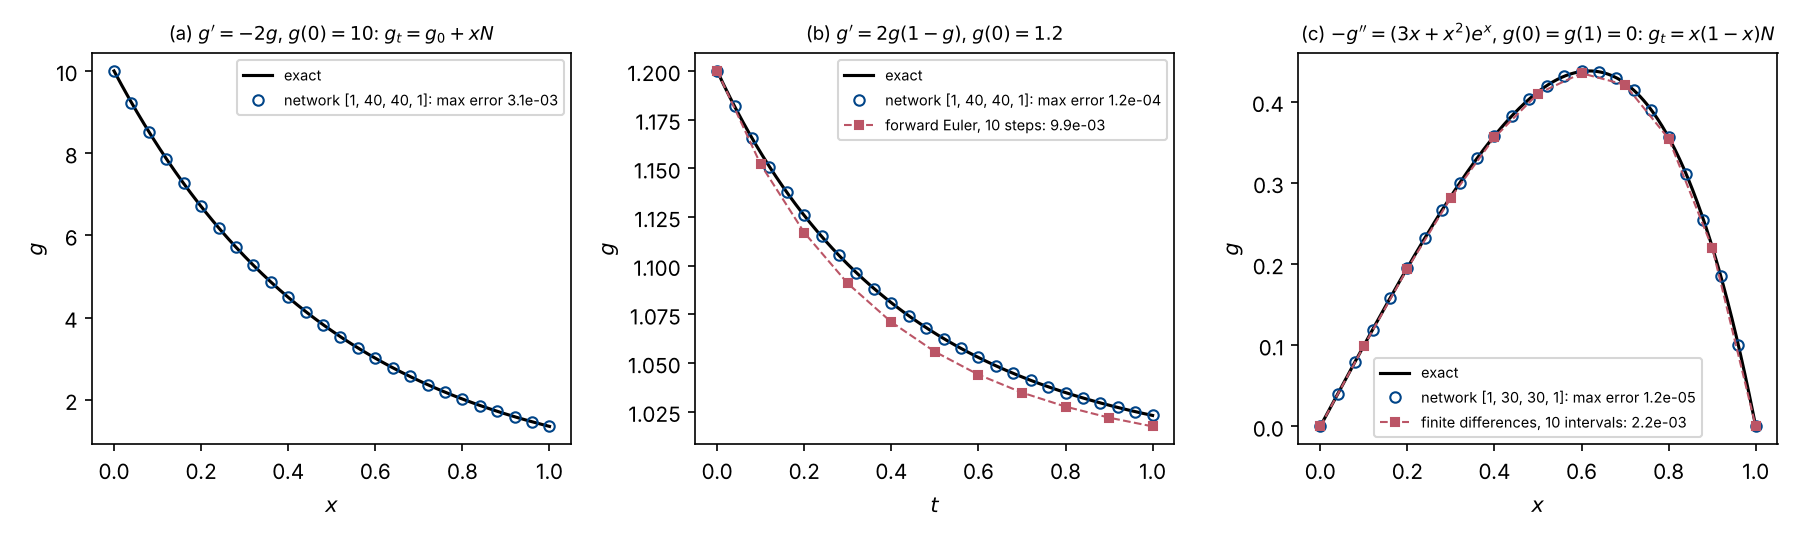

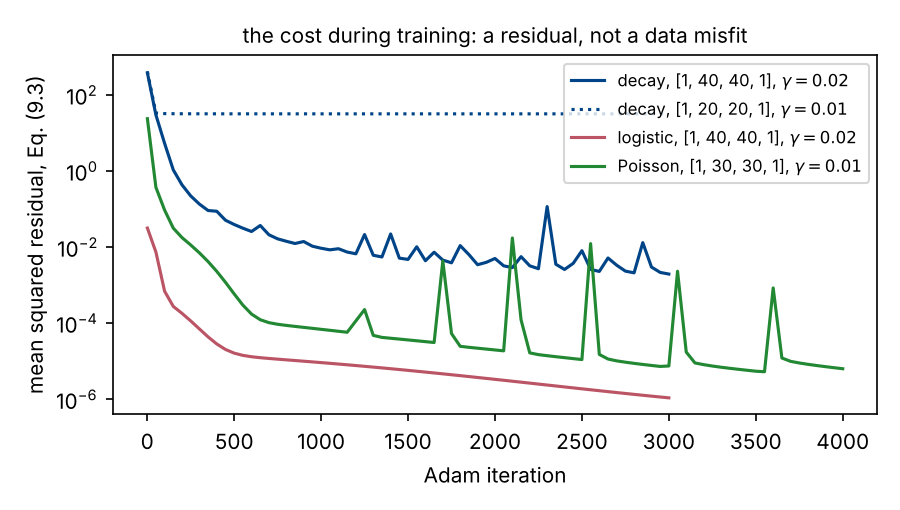

In [13]:
t0 = time.time()
odes = solve_odes()
for name in ("decay", "decay20", "logistic", "poisson", "poisson2"):
    o = odes[name]
    print(f"{name:9s} {o['sizes']} ({o['n_params']} parameters), {o['n_iter']} iterations at gamma {o['gamma']}: "
          f"final cost {o['history'][-1][1]:.3e}  max error {o['max_err']:.2e}  max |residual| {o['max_res']:.2e}  ({o['time']:.0f} s)")
for n, e in odes["euler"].items():
    print(f"Euler, {n:3d} steps (dt={1 / n:.3f}): max err {e:.2e}")
for n, e in odes["fd"].items():
    print(f"FD, {n:3d} intervals (dx={1 / n:.3f}): max err {e:.2e}")
fig_odes(odes)
fig_ode_cost(odes)
print(f"({time.time() - t0:.0f} s)")
display(Image("week42_ode.png", width=1000))
Image("week42_ode_cost.png", width=600)

The decay with forty units reaches a maximum error of $3\times10^{-3}$ on a
solution of size 10; with twenty units at $\gamma = 0.01$ the cost falls to
31.9 and stays there, and the solution is wrong by 18% — a local minimum where
the gradient is genuinely zero, the non-convexity of Section 8.7 in the flesh.
The logistic network with fifty points is ten times more accurate than Euler
with fifty steps and has no systematic lag — but Euler took microseconds and a
second-order Runge–Kutta scheme would beat the network at negligible cost. For
the Poisson equation the finite-difference error falls by four when $\Delta x$
halves, and the converged network (seed 1) sits at the hundred-interval level
with sixty points; seed 2, same architecture and $\gamma$, sits at a cost of
$0.027$ after 4000 iterations and reaches $6\times10^{-6}$ after 8000. For a
one-dimensional boundary-value problem the classical method wins decisively.

**Pause and think 4: design the trial solution.** (i) $g(0) = g_0$ and
$g'(0) = v_0$: $g_t = g_0 + v_0 x + x^2 N$, every term with $N$ carrying at
least one factor $x$ in the derivative. (ii) $g(0) = a$, $g(1) = b$: $g_t = a
+ (b-a)x + x(1-x)N$. (iii) $g(0) = 0$, $g'(1) = 0$ is the awkward one: no
prefactor alone does it, one has to subtract what the network does at the
boundary, e.g. $g_t = xN(x) - \frac12 x^2[N(1) + N'(1)]$ — a different
formula for every geometry and every type of condition, and impossible on an
L-shaped domain. That is the straitjacket Part 4 removes.

## Part 3: the diffusion equation (Sections 9.6–9.7)

A partial differential equation changes nothing but the input layer: the
network has two input nodes for $(x, t)$, `sizes = [2, 30, 30, 1]`, the
collocation points are the rows of a matrix $\boldsymbol{X}$, and the
derivatives come from `d_dxk` applied to the trial solution, one coordinate at
a time. The diffusion equation (9.26),

$$
\frac{\partial g(x,t)}{\partial t} = \frac{\partial^2 g(x,t)}{\partial x^2},\qquad
g(0,t) = g(1,t) = 0,\quad g(x,0) = u(x) = \sin\pi x,
$$

has the exact solution $g = e^{-\pi^2 t}\sin\pi x$. Three conditions, one
trial solution, Eq. (9.29):

$$
g_t(x,t,P) = (1-t)\,u(x) + x(1-x)\,t\,N(x,t,P),
$$

which satisfies all three identically for every $P$. We train on a $20\times
20$ grid, evaluate on $101\times101$, and compare with an explicit
finite-difference scheme, $u_i^{n+1} = u_i^n + \alpha(u_{i+1}^n - 2u_i^n +
u_{i-1}^n)$ with $\alpha = \Delta t/\Delta x^2 = 1/2$, the largest stable
step.

In [14]:
def diffusion_grid(nx=20, nt=20):
    xs, ts = np.linspace(0, 1, nx), np.linspace(0, 1, nt)
    Xg, Tg = np.meshgrid(xs, ts, indexing="ij")
    return xs, ts, np.column_stack([Xg.ravel(), Tg.ravel()])


def exact_diffusion(x, t, D=1.0):
    return np.exp(-D * np.pi ** 2 * t) * np.sin(np.pi * x)


def trial_diffusion(layers, X):
    """Eq. (9.29): g_t = (1-t) sin(pi x) + x(1-x) t N(x,t) -- all three conditions hold identically."""
    x, t = X[:, 0], X[:, 1]
    return (1 - t) * jnp.sin(jnp.pi * x) + x * (1 - x) * t * network(layers, X, "tanh")


def residual_diffusion(layers, X):
    """Eq. (9.26): dg/dt - d2g/dx2, both derivatives of the TRIAL solution by nested AD."""
    g_t = d_dxk(trial_diffusion, 1)
    g_xx = d_dxk(d_dxk(trial_diffusion, 0), 0)
    return g_t(layers, X) - g_xx(layers, X)


def evaluate_diffusion(g_fun, layers, n_eval=101):
    """Errors on a 101 x 101 grid: max, rmse, max on the line t = 0, and the error map."""
    xe, te = np.linspace(0, 1, n_eval), np.linspace(0, 1, n_eval)
    Xe, Te = np.meshgrid(xe, te, indexing="ij")
    Xeval = jnp.asarray(np.column_stack([Xe.ravel(), Te.ravel()]))
    g = np.asarray(g_fun(layers, Xeval)).reshape(n_eval, n_eval)
    err = np.abs(g - exact_diffusion(Xe, Te))
    return {"max": err.max(), "rmse": np.sqrt(np.mean(err ** 2)), "t0": err[:, 0].max(), "map": err,
            "x": xe, "t": te, "g": g, "argmax": (xe[np.unravel_index(err.argmax(), err.shape)[0]],
                                                 te[np.unravel_index(err.argmax(), err.shape)[1]])}


def fd_diffusion(nx=21, T=1.0, alpha=0.5, times=(0.1, 0.3, 0.5)):
    """Explicit (forward Euler) finite differences for Eq. (9.26) with dt = alpha dx^2, alpha <= 1/2 for stability."""
    x = np.linspace(0, 1, nx)
    dx = x[1] - x[0]
    dt = alpha * dx ** 2
    n_steps = int(round(T / dt))
    u = np.sin(np.pi * x)
    t = 0.0
    snapshots, max_err = {}, []
    for step in range(n_steps):
        u[1:-1] = u[1:-1] + alpha * (u[2:] - 2 * u[1:-1] + u[:-2])    # u^{n+1}_i = u^n_i + alpha (u_{i+1} - 2u_i + u_{i-1})
        t += dt
        max_err.append((t, np.abs(u - exact_diffusion(x, t)).max()))
        for ts in times:
            if abs(t - ts) < dt / 2:
                snapshots[ts] = u.copy()
    return x, snapshots, np.array(max_err), dt, n_steps


def solve_diffusion_hard(n_iter=800, verbose=False):
    xs, ts, X = diffusion_grid()
    t0 = time.time()
    layers, hist = solve_de(residual_diffusion, [2, 30, 30, 1], X, "tanh", n_iter=n_iter, gamma=1e-2,
                            rng=np.random.default_rng(1), verbose=verbose)
    ev = evaluate_diffusion(trial_diffusion, layers)
    ev.update({"layers": layers, "history": hist, "time": time.time() - t0, "n_iter": n_iter})
    return ev


def fig_diffusion(ev, fname="week42_diffusion.pdf"):
    x, snaps, fd_err, dt, n_steps = fd_diffusion()
    fig, ax = plt.subplots(1, 3, figsize=(12, 3.6))
    for ts, col in zip((0.0, 0.1, 0.3, 0.5), ("k", BLUE, RED, GREEN)):
        it = int(round(ts * 100))
        ax[0].plot(ev["x"], exact_diffusion(ev["x"], ev["t"][it]), color=col, lw=1.5, label=f"$t={ev['t'][it]:.2f}$ exact")
        ax[0].plot(ev["x"][::6], ev["g"][::6, it], "o", color=col, ms=4, mfc="none")
        if ts in snaps:
            ax[0].plot(x, snaps[ts], "s", color=col, ms=3, alpha=0.6)
    ax[0].plot([], [], "o", color=GREY, mfc="none", label="network, Eq. (9.29)")
    ax[0].plot([], [], "s", color=GREY, label=f"explicit FD, $\\Delta x=0.05$")
    ax[0].set_xlabel("$x$")
    ax[0].set_ylabel("$g(x,t)$")
    ax[0].legend(fontsize=7)
    ax[0].set_title("(a) time slices", fontsize=10)
    im = ax[1].imshow(ev["map"].T, origin="lower", extent=[0, 1, 0, 1], aspect="auto", cmap="viridis")
    fig.colorbar(im, ax=ax[1])
    ax[1].set_xlabel("$x$")
    ax[1].set_ylabel("$t$")
    ax[1].set_title(f"(b) $|g_t-g|$, max {ev['max']:.1e}, exactly 0 on three edges", fontsize=10)
    ax[2].semilogy(ev["t"], ev["map"].max(axis=0), color=BLUE, lw=2, label=f"network, {ev['n_iter']} Adam iterations")
    ax[2].semilogy(fd_err[:, 0], fd_err[:, 1], color=RED, lw=1.5, ls="--", label=f"explicit FD, {n_steps} steps of $\\Delta t={dt:.4f}$")
    ax[2].semilogy(ev["t"], np.exp(-np.pi ** 2 * ev["t"]), color=GREY, lw=1, ls=":", label=r"the solution itself, $e^{-\pi^2 t}$")
    ax[2].set_xlabel("$t$")
    ax[2].set_ylabel("max error over $x$")
    ax[2].set_ylim(1e-7, 1)
    ax[2].legend(fontsize=7)
    ax[2].set_title("(c) error against time, both methods", fontsize=10)
    fig.tight_layout()
    fig.savefig(fname)
    fig.savefig(fname.replace(".pdf", ".png"), dpi=150)
    plt.close(fig)
    return {"fd_max": fd_err[:, 1].max(), "fd_dt": dt, "fd_steps": n_steps}


hard,  800 iterations: max error 1.04e-02  rmse 1.79e-03  error at t=0 0.0e+00  largest at x=0.420, t=0.050  (3 s)


hard, 4000 iterations: max error 1.09e-02  rmse 1.68e-03  error at t=0 0.0e+00  largest at x=0.470, t=0.040  (7 s)
  t=0.000: max err 0.00e+00
  t=0.100: max err 2.71e-03
  t=0.300: max err 1.35e-03


explicit FD, dx = 0.05, dt = 0.00125 (800 steps): max error 1.52e-03
(12 s)


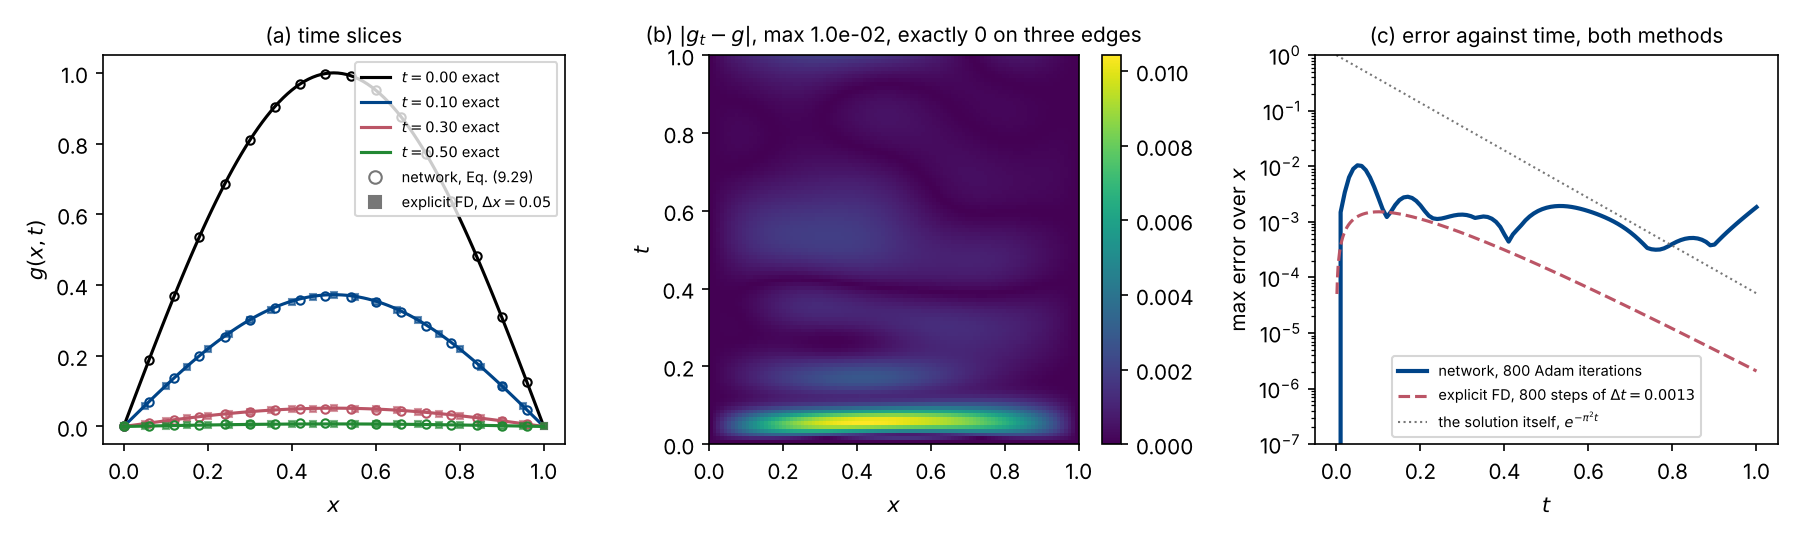

In [15]:
t0 = time.time()
hard = {}
for n_iter in (800, 4000):
    hard[n_iter] = solve_diffusion_hard(n_iter=n_iter)
    h = hard[n_iter]
    print(f"hard, {n_iter:4d} iterations: max error {h['max']:.2e}  rmse {h['rmse']:.2e}  error at t=0 {h['t0']:.1e}  "
          f"largest at x={h['argmax'][0]:.3f}, t={h['argmax'][1]:.3f}  ({h['time']:.0f} s)")
for it in (0, 10, 30):
    print(f"  t={hard[800]['t'][it]:.3f}: max err {hard[800]['map'][:, it].max():.2e}")
fdinfo = fig_diffusion(hard[800])
print(f"explicit FD, dx = 0.05, dt = {fdinfo['fd_dt']:.5f} ({fdinfo['fd_steps']} steps): max error {fdinfo['fd_max']:.2e}")
print(f"({time.time() - t0:.0f} s)")
Image("week42_diffusion.png", width=1000)

The error at $t = 0$ is *exactly* zero — not small, zero to machine
precision, at every stage of training — and so is the error along $x = 0$ and
$x = 1$, because Eq. (9.29) satisfies the conditions identically. The largest
error, $10^{-2}$, sits at small non-zero times where the solution changes
fastest; 4000 iterations do not improve on 800. The explicit scheme reaches
$1.5\times10^{-3}$ in milliseconds, and its error decays *with* the solution,
while the network's absolute error stays near $10^{-3}$ for all $t$.

**Pause and think 5: an absolute error that does not decay.** At $t = 1$ the
solution is $5\times10^{-5}$ and the network's error is still $10^{-3}$: a
relative error above one. The cost is a mean of squared *absolute* residuals
over points spread uniformly over the domain, so Adam spends its effort where
the residual is large, at early times, and a region where the solution is
$10^{-4}$ contributes nothing. Remedies: more collocation points or weights at
late times (the beginning of the weighting problem of Part 4), a relative
residual or the equation for $\ln g$, or building the decay into the trial
solution — information put into the ansatz is free and exact, information
requested through the cost is paid for in optimisation effort.

## Part 4: physics-informed neural networks (Section 9.10)

Constructing $h_1$ and $h_2$ by hand is a straitjacket: easy on the unit box
with homogeneous Dirichlet conditions, tedious to impossible for a curved
boundary, a Neumann condition, a coupled system or an L-shaped domain. The
physics-informed neural network takes the opposite view: the network itself is
the solution, $u(\boldsymbol{x}) \approx N(\boldsymbol{x}, P)$, Eq. (9.34),
and the conditions are demanded of the optimiser, one least-squares penalty
each — *soft* constraints in place of the *hard* ones of the trial solution.
Four point sets instead of one (interior collocation points, the line $t = 0$,
the two boundaries), and the composite cost (9.38),

$$
L_{\mathrm{total}}(P) = L_{\mathrm{PDE}} + \lambda_{\mathrm{IC}} L_{\mathrm{IC}} + \lambda_{\mathrm{BC}} L_{\mathrm{BC}},
$$

with $L_{\mathrm{PDE}}$ exactly the cost we have minimised all along, with $N$
in place of $g_t$, and the weights $\lambda$ in the role of the penalty
parameters of Ridge regression. At the level of code: one point set becomes
several, and the cost acquires weights. The collocation points deliberately
exclude the boundaries — a point carrying both the equation residual and a
boundary residual is asked two things at once. We solve exactly the problem of
Part 3, with the same network, optimiser and seed, so that the two
formulations can be compared on identical ground.

In [16]:
def u_net(layers, X):
    """Eq. (9.34): the network itself is the solution, no trial-solution scaffolding."""
    return network(layers, X, "tanh")



u_t = d_dxk(u_net, 1)
u_xx = d_dxk(d_dxk(u_net, 0), 0)


def r_pde(layers, X):
    """Eq. (9.35): the equation residual on the collocation points."""
    return u_t(layers, X) - u_xx(layers, X)


def r_ic(layers, X):
    """Eq. (9.36): the initial condition, N(x, 0) - sin(pi x)."""
    return u_net(layers, X) - jnp.sin(jnp.pi * X[:, 0])


def r_bc(layers, X):
    """Eq. (9.37): the boundary conditions, N(0, t) and N(1, t)."""
    return u_net(layers, X)


def pinn_points(nx=20, nt=20):
    """Four point sets: interior collocation points, the line t = 0, and the two boundaries x = 0 and x = 1."""
    xs, ts = np.linspace(0, 1, nx), np.linspace(0, 1, nt)
    Xi, Ti = np.meshgrid(xs[1:-1], ts[1:-1], indexing="ij")
    X_col = np.column_stack([Xi.ravel(), Ti.ravel()])        # 324 interior points
    X_ic = np.column_stack([xs, np.zeros(nx)])
    X_l = np.column_stack([np.zeros(nt), ts])
    X_r = np.column_stack([np.ones(nt), ts])
    return [jnp.asarray(A) for A in (X_col, X_ic, X_l, X_r)]


def pinn_solve(terms, sizes, activation="tanh", n_iter=2000, gamma=1e-2, rng=None, every=50, verbose=False):
    """terms: list of (name, weight, residual_fn, points), Eq. (9.38): the cost is a weighted sum of mean squared residuals.

    The history records the four unweighted terms, so that we can watch them
    trade against one another during training.
    """
    layers = to_jax(create_layers(sizes, activation, rng))

    def cost_fn(layers):
        return sum(w * jnp.mean(residual(layers, Xk) ** 2) for _, w, residual, Xk in terms)

    terms_fn = jax.jit(lambda layers: jnp.array([jnp.mean(residual(layers, Xk) ** 2) for _, _, residual, Xk in terms]))
    return adam_minimise(cost_fn, layers, n_iter=n_iter, gamma=gamma, every=every, trace_fn=terms_fn, verbose=verbose)


def solve_diffusion_soft(lam=10.0, n_iter=800, verbose=False):
    """The problem of Section 9.7 once more, now with the four point sets and the weighted cost of Eq. (9.38)."""
    X_col, X_ic, X_l, X_r = pinn_points()
    terms = [("pde", 1.0, r_pde, X_col), ("ic", lam, r_ic, X_ic), ("bcL", lam, r_bc, X_l), ("bcR", lam, r_bc, X_r)]
    t0 = time.time()
    layers, hist = pinn_solve(terms, [2, 30, 30, 1], "tanh", n_iter=n_iter, gamma=1e-2,
                              rng=np.random.default_rng(1), every=10, verbose=verbose)
    ev = evaluate_diffusion(u_net, layers)
    ev.update({"layers": layers, "history": hist, "time": time.time() - t0, "n_iter": n_iter, "lam": lam,
               "terms": np.array(hist[-1][2:]), "trace": np.array([(h[0],) + tuple(h[2:]) for h in hist])})
    return ev


def fig_pinn(soft, hard, fname="week42_pinn.pdf"):
    fig, ax = plt.subplots(1, 3, figsize=(12, 3.6))
    tr = soft["trace"]
    for k, (name, col) in enumerate((("$L_{\\mathrm{PDE}}$", BLUE), ("$L_{\\mathrm{IC}}$", RED),
                                     ("$L_{\\mathrm{BC}}$, $x=0$", GREEN), ("$L_{\\mathrm{BC}}$, $x=1$", YELLOW))):
        ax[0].semilogy(tr[:, 0], tr[:, k + 1], color=col, lw=1.2, label=name)
    ax[0].set_xlabel("Adam iteration")
    ax[0].set_ylabel("mean squared residual of each term")
    ax[0].legend(fontsize=7)
    ax[0].set_title(rf"(a) the four terms of Eq. (9.38), $\lambda={soft['lam']:g}$", fontsize=10)
    im = ax[1].imshow(soft["map"].T, origin="lower", extent=[0, 1, 0, 1], aspect="auto", cmap="viridis")
    fig.colorbar(im, ax=ax[1])
    ax[1].set_xlabel("$x$")
    ax[1].set_ylabel("$t$")
    ax[1].set_title(f"(b) soft constraints: $|N-g|$, max {soft['max']:.1e}", fontsize=10)
    ax[2].plot(soft["x"], soft["map"][:, 0], color=RED, lw=2, label=f"soft, {soft['n_iter']} iterations: max {soft['t0']:.1e}")
    ax[2].plot(hard["x"], hard["map"][:, 0], color=BLUE, lw=2, label=f"hard, Eq. (9.29): exactly 0")
    ax[2].set_xlabel("$x$")
    ax[2].set_ylabel(r"$|g_t(x,0)-\sin\pi x|$")
    ax[2].legend(fontsize=8)
    ax[2].set_title("(c) the initial condition at $t=0$", fontsize=10)
    fig.tight_layout()
    fig.savefig(fname)
    fig.savefig(fname.replace(".pdf", ".png"), dpi=150)
    plt.close(fig)


formulation        iterations   max error     rmse      error at t=0
hard, Eq. (9.29)        800     1.04e-02   1.79e-03   0.0e+00
hard, Eq. (9.29)       4000     1.09e-02   1.68e-03   0.0e+00


soft, lambda =     1    800     2.93e-02   4.12e-03   2.93e-02   terms (pde, ic, bcL, bcR) [0.0009 0.0002 0.     0.0001]


soft, lambda =    10    800     3.51e-02   1.35e-02   3.51e-02   terms (pde, ic, bcL, bcR) [0.0021 0.0005 0.0001 0.0003]


soft, lambda =   100    800     4.00e-02   7.06e-03   1.48e-02   terms (pde, ic, bcL, bcR) [0.0102 0.0001 0.     0.    ]


soft, lambda =    10   4000     3.18e-02   6.45e-03   6.29e-03   terms (pde, ic, bcL, bcR) [0.0004 0.     0.     0.    ]


(17 s)


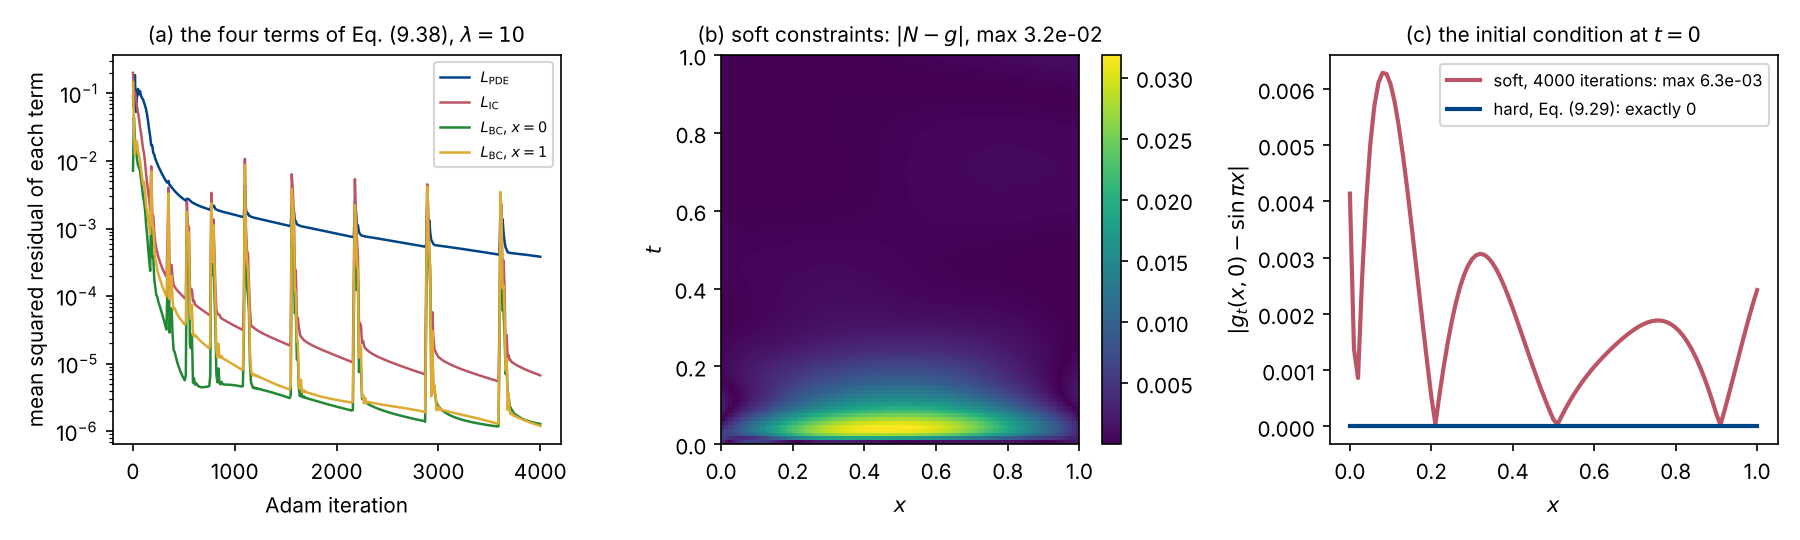

In [17]:
t0 = time.time()
soft = {}
print("formulation        iterations   max error     rmse      error at t=0")
for n_iter in (800, 4000):
    h = hard[n_iter]
    print(f"hard, Eq. (9.29)      {n_iter:5d}     {h['max']:.2e}   {h['rmse']:.2e}   {h['t0']:.1e}")
for lam, n_iter in ((1.0, 800), (10.0, 800), (100.0, 800), (10.0, 4000)):
    soft[(lam, n_iter)] = solve_diffusion_soft(lam=lam, n_iter=n_iter)
    sft = soft[(lam, n_iter)]
    print(f"soft, lambda = {lam:5.0f}  {n_iter:5d}     {sft['max']:.2e}   {sft['rmse']:.2e}   {sft['t0']:.2e}   "
          f"terms (pde, ic, bcL, bcR) {sft['terms']}")
fig_pinn(soft[(10.0, 4000)], hard[800])
print(f"({time.time() - t0:.0f} s)")
Image("week42_pinn.png", width=1000)

The hard formulation wins on every measure: RMSE three to four times
smaller, and the error at $t = 0$ not merely smaller but zero. Five times more
training does not close the gap. Raising $\lambda$ from 1 to 10 changes
little, 100 makes everything worse ($L_{\mathrm{PDE}}$ rises tenfold): there
is a best $\lambda$, it is problem-dependent, and we found it by trying three
values. The reason is conditioning — the four terms have gradients of very
different sizes and one learning rate must serve all of them; panel (a) shows
them trading against one another. *On a problem where a trial solution can be
constructed, constructing it is better.*

### So why soft constraints at all? The inverse problem (Eqs. 9.39–9.40)

Suppose the diffusion coefficient $D$ in $\partial_t u = D\,\partial_x^2 u$
is *unknown*, and instead of initial and boundary conditions we have forty
noisy measurements of the solution at scattered points. We minimise

$$
L(P, D) = \frac{1}{N_{\mathrm{pde}}}\sum_i \Bigl(\partial_t N - D\,\partial_x^2 N\Bigr)_i^2
+ \lambda_{\mathrm{data}}\frac{1}{N_{\mathrm{data}}}\sum_i \bigl(N(\boldsymbol{x}_i, P) - y_i\bigr)^2
$$

over the weights *and* $D$ together: no initial condition, no boundary
condition, the data replace them. A trial solution cannot even be written
down. For Adam, $D$ is one more leaf of the parameter tree.

In [18]:
D_TRUE = 0.5


def observations(n_obs=40, noise=0.01, seed=3):
    rng = np.random.default_rng(seed)
    X_obs = np.column_stack([rng.uniform(0, 1, n_obs), rng.uniform(0, 1, n_obs)])
    y_obs = exact_diffusion(X_obs[:, 0], X_obs[:, 1], D_TRUE) + rng.normal(0, noise, n_obs)
    return jnp.asarray(X_obs), jnp.asarray(y_obs)


def pinn_inverse(X_obs, y_obs, D0=2.0, n_iter=3000, lam_data=10.0, every=50, verbose=False):
    """Minimise Eq. (9.40) over the weights AND the coefficient D: no initial or boundary conditions, the data replace them."""
    X_col = pinn_points()[0]
    params = (to_jax(create_layers([2, 30, 30, 1], "tanh", np.random.default_rng(1))), jnp.array(D0))

    def cost_fn(params):
        layers, D = params                                    # the only line that knows this is an inverse problem
        return (jnp.mean((u_t(layers, X_col) - D * u_xx(layers, X_col)) ** 2)
                + lam_data * jnp.mean((u_net(layers, X_obs) - y_obs) ** 2))

    params, hist = adam_minimise(cost_fn, params, n_iter=n_iter, gamma=1e-2, every=every,
                                 trace_fn=lambda p: p[1], verbose=False)
    if verbose:
        for it, c, D in hist:
            if it == 1 or it % 500 == 0:
                print(f"  it {it:5d}  cost {c:.4e}  D {D:.6f}")
    return params, np.array(hist)


def fig_pinn_inverse(runs, X_obs, y_obs, fname="week42_pinn_inverse.pdf"):
    fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
    for (D0, params, trace), col in zip(runs, (BLUE, RED, GREEN)):
        ax[0].plot(trace[:, 0], trace[:, 2], color=col, lw=1.5, label=f"$D_0={D0}$: $D={float(params[1]):.4f}$")
    ax[0].axhline(D_TRUE, color="k", lw=1, ls="--", label=f"$D_{{\\mathrm{{true}}}}={D_TRUE}$")
    ax[0].set_xlabel("Adam iteration")
    ax[0].set_ylabel("$D$")
    ax[0].set_yscale("log")
    ax[0].legend(fontsize=8)
    ax[0].set_title("(a) the coefficient during training, three starts", fontsize=10)
    layers, D = runs[0][1]
    xx = np.linspace(0, 1, 200)
    X_obs, y_obs = np.asarray(X_obs), np.asarray(y_obs)
    for ts, col in zip((0.05, 0.3, 0.7), (BLUE, RED, GREEN)):
        Xs = jnp.asarray(np.column_stack([xx, np.full_like(xx, ts)]))
        ax[1].plot(xx, np.asarray(u_net(layers, Xs)), color=col, lw=2, label=f"$t={ts}$: network")
        ax[1].plot(xx, exact_diffusion(xx, ts, D_TRUE), color=col, lw=1, ls="--")
    sc = ax[1].scatter(X_obs[:, 0], y_obs, c=X_obs[:, 1], cmap="viridis", s=18, edgecolor="k", lw=0.3, label="40 noisy observations")
    fig.colorbar(sc, ax=ax[1], label="$t$ of the observation")
    ax[1].plot([], [], color=GREY, ls="--", label="exact, dashed")
    ax[1].set_xlabel("$x$")
    ax[1].set_ylabel("$u(x,t)$")
    ax[1].legend(fontsize=7)
    ax[1].set_title(f"(b) the recovered solution, $D={float(D):.3f}$", fontsize=10)
    fig.tight_layout()
    fig.savefig(fname)
    fig.savefig(fname.replace(".pdf", ".png"), dpi=150)
    plt.close(fig)


  it     1  cost 7.3847e-01  D 1.990000
  it   500  cost 2.5258e-02  D 1.669948
  it  1000  cost 7.1362e-03  D 0.638616
  it  1500  cost 2.8731e-03  D 0.494322
  it  2000  cost 2.0003e-03  D 0.508263
  it  2500  cost 1.4834e-03  D 0.506938
  it  3000  cost 1.3360e-03  D 0.513255
D0 = 2.0: recovered D = 0.5133, relative error 2.65%


D0 = 1.0: recovered D = 0.5148, relative error 2.96%


D0 = 0.1: recovered D = 0.5124, relative error 2.48%


noise 0.0: recovered D = 0.4762, relative error 4.77%


noise 0.05: recovered D = 0.6903, relative error 38.05%
(38 s)


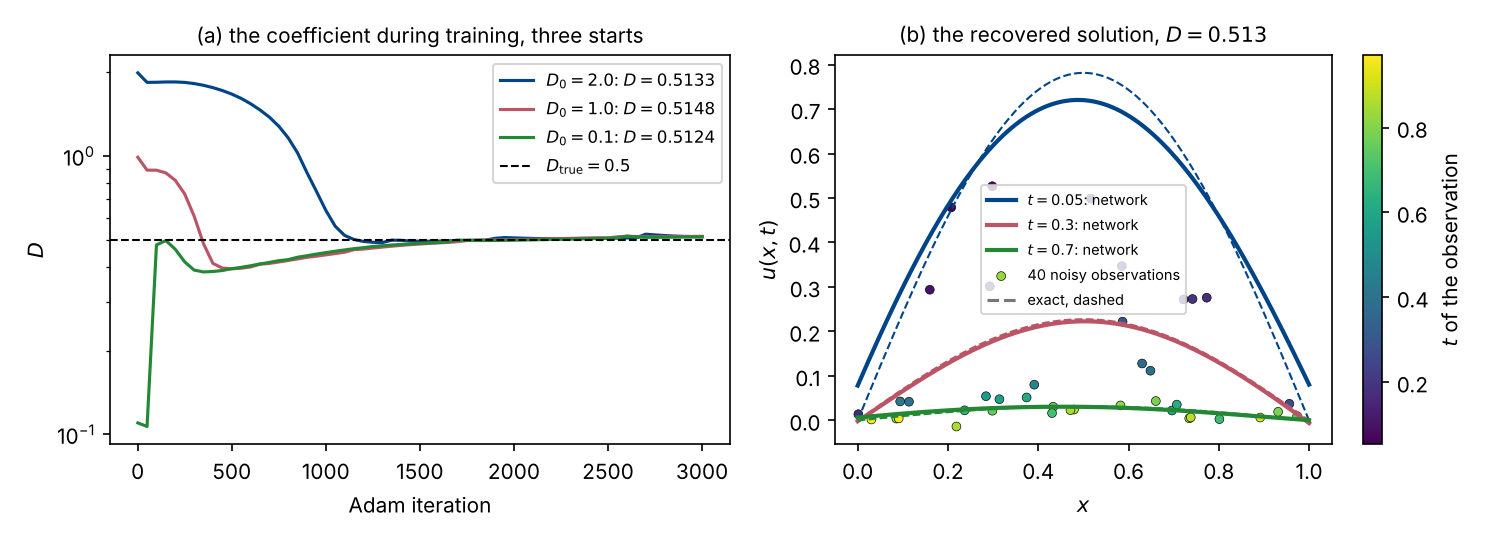

In [19]:
t0 = time.time()
X_obs, y_obs = observations()
runs = []
for D0 in (2.0, 1.0, 0.1):
    params, trace = pinn_inverse(X_obs, y_obs, D0=D0, verbose=(D0 == 2.0))
    runs.append((D0, params, trace))
    print(f"D0 = {D0}: recovered D = {float(params[1]):.4f}, relative error {100 * abs(float(params[1]) - D_TRUE) / D_TRUE:.2f}%")
fig_pinn_inverse(runs, X_obs, y_obs)
for noise in (0.0, 0.05):
    Xo, yo = observations(noise=noise)
    params, _ = pinn_inverse(Xo, yo, D0=2.0)
    print(f"noise {noise}: recovered D = {float(params[1]):.4f}, relative error {100 * abs(float(params[1]) - D_TRUE) / D_TRUE:.2f}%")
print(f"({time.time() - t0:.0f} s)")
Image("week42_pinn_inverse.png", width=900)

Forty noisy points and no boundary information at all recover the
coefficient to three per cent, from three different starting values. The
result should not be oversold: five per cent noise on the observations gives
thirty-eight per cent error in $D$. Inverse problems are ill-posed, and the
sensitivity belongs to the problem, not to the method.

**Pause and think 6: forty points, no conditions, three per cent — and then
thirty-eight.** What supplied the missing conditions? The observations,
together with the equation, which propagates each measurement through space
and time; conditions are information and data are information, and the cost
only counts residuals. The collapse at 5% noise is not the method's fault — a
classical adjoint-based inversion on the same forty points would face the same
amplification. Recovering a parameter from data is a statistical estimation
problem: bootstrap the observations or vary the seed, and report $D$ with an
error bar.

## Summary

- **The reminder:** the forward pass, the four equations with their two
  transposes, the five decisions of the algorithm; the hidden activation must
  be non-polynomial and enters the backward pass only through $f'$; the output
  activation follows the range of the target, the cost its distribution, and
  for the three natural pairings the output error is $\boldsymbol{a}^L -
  \boldsymbol{y}$.
- **Differential equations without data:** the trial solution carries the
  conditions exactly, the mean squared residual is the cost, the derivatives
  with respect to the input come from the forward recursions or nested AD, and
  ReLU has $f'' \equiv 0$ — hence $\tanh$. Decay, logistic growth, Poisson:
  $10^{-3}$, $10^{-4}$, $10^{-5}$, with one run stuck at 31.9 and one seed
  that needed twice the iterations. Classical methods win on speed; the
  network returns a function.
- **The diffusion equation:** error exactly zero on three edges, $10^{-2}$
  at $t = 0.05$, $10^{-3}$ absolute everywhere — a relative error above one at
  $t = 1$.
- **PINNs:** soft constraints lose to hard ones whenever both are available
  and the weights are a conditioning problem; but with an unknown $D$ and
  forty noisy points the soft formulation is the only one, and recovers $D$ to
  three per cent — an estimate that needs an error bar.

**Tuesday:** your questions, then one case — the backward pass of this week's
exercises, step by step, with the shapes. **Exercises week 42** are due Friday
October 16 at midnight; **Project 2** (deadline November 6) builds on the code
of Part 1.